# SIND Pipeline v2 — Multi-Architecture Bayesian Network Comparison


### Sections
| # | Section | Purpose |
|---|---------|---------|
| 0 | Imports & Configuration | — |
| 1 | Data Loading | — |
| 2 | Unified Metrics Module | Single source of truth for every reported metric |
| 3 | Preprocessing Pipeline | Discretisation + latent (domain) nodes via KMeans |
| 4 | Bayesian Network Architectures | The 6 architectures + 2 structure-learning techniques |
| 5 | Threshold Calibration Toolkit | 4 threshold-selection strategies |
| 6 | Repeated Stratified K-Fold Evaluation | Architecture comparison, N=30 paired folds |
| 7 | Statistical Tests — Wilcoxon | Best architecture vs. every other, paired |
| 8 | Best-Architecture Selection & Final Run | Canonical Train/Val/Test evaluation |
| 9 | SMOTE Ablation | Best architecture only |
| 10 | Imbalance Sensitivity | Best architecture only |
| 11 | CPT Stability (Bootstrap) | Best architecture only |
| 12 | MAP vs. MLE Analysis | Best architecture only |
| 13 | Runtime Analysis | All 6 architectures |
| 14 | Final Architecture — Interpretability | CPD tables + interpretive graph |
| 15 | Export All Results | File inventory |

### The six architectures

| Key | Name | Structure | Latent nodes? | How dependencies are found |
|-----|------|-----------|:---:|------|
| `NB` | Naive Bayes | `label → every feature` | No | — (control / no structure) |
| `SNBN` | Semi-Naive (original SIND) | `label → every feature` + fixed intra-domain feature chain | No | Manually fixed (domain order), **unchanged from the previous pipeline** |
| `HL` | Hierarchical Latent (fixed) | `label → latent_d → features_d` | Yes | Manually fixed hierarchy, **no** dependency between latents (ablation baseline) |
| `TAN-F` | TAN over Features | `label → every feature` + Chow-Liu max-spanning tree among features | No | **ML-learned** (Chow-Liu / mutual information) |
| `SIND-CL` | SIND + Latent Structure (Chow-Liu) | `label → latent_d → features_d` + Chow-Liu tree **among latents** | Yes | **ML-learned** (Chow-Liu / mutual information) |
| `SIND-HC` | SIND + Latent Structure (HillClimb) | `label → latent_d → features_d` + HillClimb-searched edges **among latents** | Yes | **ML-learned** (score-based greedy search, BIC) |

`SIND-CL` and `SIND-HC` are architecturally identical except for *how* the
inter-domain (latent-latent) dependencies are discovered — this isolates the
effect of the structure-learning technique itself, and directly answers the
revision requirement that "the relationship between latent nodes must be
found through a Machine Learning technique."

> **Note on causal language.** Edges
> represent probabilistic dependencies informed by data and by domain
> structure, not verified causal relationships.


## 0. Imports & Configuration

In [1]:
# ── 0.1 Install (uncomment if needed) ──────────────────────────────────────
!pip install pgmpy scikit-learn imbalanced-learn scipy networkx seaborn

import pandas as pd
import numpy as np
import warnings
import time
import json
from copy import deepcopy
from collections import defaultdict
from itertools import permutations

warnings.filterwarnings('ignore')

# sklearn — used only for discretisation, clustering (latent nodes), metrics,
# splitting/cross-validation and threshold calibration. NOT for classification
# baselines (removed in this revision — see header note).
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, average_precision_score, roc_curve
)
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold
from sklearn.cluster import KMeans
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression as _LR
from sklearn.isotonic import IsotonicRegression

# imbalanced-learn — SMOTE ablation only (Section 9)
from imblearn.over_sampling import SMOTE

# pgmpy — Bayesian Network modelling, parameter estimation and inference
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.parameter_estimator import DiscreteMLE, DiscreteBayesianEstimator
from pgmpy.inference import VariableElimination

# pgmpy — structure learning (the ML techniques used to find latent-latent
# and feature-feature dependencies):
#   TreeSearch       -> Chow-Liu / TAN (maximum mutual-information tree)
#   HillClimbSearch  -> score-based greedy search with tabu list
#   ExpertKnowledge  -> constrains HillClimbSearch to a restricted edge set
from pgmpy.estimators import TreeSearch
from pgmpy.causal_discovery import HillClimbSearch, ExpertKnowledge

# scipy — Wilcoxon signed-rank test
from scipy.stats import wilcoxon, norm as _norm

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import networkx as nx
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.1)
print("All libraries loaded")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 65.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.1/236.1 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 169.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 23.7 MB/s eta 0:00:00
All libraries loaded


In [ ]:
# ── 0.2 Global Configuration ───────────────────────────────────────────────
RANDOM_STATE        = 42
N_BINS              = 8          # discretisation bins per feature
STRATEGY            = 'quantile'
N_LATENT_STATES     = 3          # KMeans states per domain (latent node cardinality)

N_SPLITS_CV         = 10
N_REPEATS_CV        = 3

N_BOOTSTRAP         = 1000       # bootstrap resamples for 95% CI on summary metrics
N_BOOT_CPT          = 100        # bootstrap resamples for CPT stability (Section 11)
TOP_N_CPT_NODES     = 10          # number of highest-MI nodes to track for CPT stability

# Threshold calibration (used for the FINAL canonical run in Section 8; the
# CV loop in Section 6 uses the faster Youden's J rule per fold)
VAL_SIZE            = 0.20       # 20% of X_train reserved for validation
THRESHOLD_GRID      = np.arange(0.05, 0.95, 0.01)
THRESHOLD_CRITERION = 'f1'       # 'f1' | 'recall' | 'balanced'

# BN parameter-estimation hyper-parameters
BN_PRIOR_TYPE       = 'BDeu'
BN_ESS_DEFAULT      = 5          # equivalent sample size (default MAP prior strength)

# Imbalance sensitivity ratios (minority-class fraction, Section 10)
IMBALANCE_RATIOS    = [0.01, 0.02, 0.05, 0.10, 0.20, 0.30]

# MAP ESS grid for MAP vs MLE analysis (Section 12)
ESS_GRID            = [1, 5, 10, 20]

print("Configuration set")
print(f"  N_SPLITS_CV x N_REPEATS_CV = {N_SPLITS_CV} x {N_REPEATS_CV} = "
      f"{N_SPLITS_CV*N_REPEATS_CV} paired folds for Wilcoxon")
print(f"  N_BOOTSTRAP  = {N_BOOTSTRAP}")
print(f"  VAL_SIZE     = {VAL_SIZE}")
print()
print("Runtime note: exact inference (VariableElimination) is run once per")
print("unique discretised evidence row (cached), for every fold and every")
print("architecture. On a dataset of this size (~1,250 rows total) the full")
print("Section 6 loop is expected to take a few minutes; if it is too slow,")
print("reduce N_REPEATS_CV (statistical power drops accordingly).")


Configuration set
  N_SPLITS_CV x N_REPEATS_CV = 10 x 3 = 30 paired folds for Wilcoxon
  N_BOOTSTRAP  = 1000
  VAL_SIZE     = 0.2

Runtime note: exact inference (VariableElimination) is run once per
unique discretised evidence row (cached), for every fold and every
architecture. On a dataset of this size (~1,250 rows total) the full
Section 6 loop is expected to take a few minutes; if it is too slow,
reduce N_REPEATS_CV (statistical power drops accordingly).


## 1. Data Loading

In [17]:
# ── 1.1 Load pre-split data ────────────────────────────────────────────────
# Assumes X_train.csv / X_test.csv / y_train.csv / y_test.csv exist
# (generated by Extração_de_Features.ipynb)
X_train = pd.read_csv('./X_train.csv')
X_test  = pd.read_csv('./X_test.csv')
y_train = pd.read_csv('./y_train.csv').squeeze()
y_test  = pd.read_csv('./y_test.csv').squeeze()

# ── 1.2 Top-24 features (unchanged from the original SIND selection) ──────
TOP_FEATURES = [
    'device_std_daily_device_events',  'logon_total_logoffs_day',
    'device_mean_daily_device_events', 'email_email_total_attachments',
    'email_email_unique_bcc',          'device_offhour_device_ratio',
    'device_active_days',              'logon_distinct_pcs_used',
    'logon_sessions_total_duration',   'logon_missing_logoff_count',
    'file_pdf_files_accessed',         'file_exe_files_accessed',
    'email_email_unique_to',           'logon_open_sessions_mean',
    'logon_total_logons_day',          'email_n_email',
    'logon_logon_to_logoff_ratio',     'email_email_mean_text_len',
    'device_max_daily_device_events',  'device_offhour_device_count',
    'device_device_events_total',      'device_unique_pcs_used',
    'device_usb_connects',             'http_unique_urls_visited',
]
TOP_FEATURES = [f for f in TOP_FEATURES if f in X_train.columns]

# ── 1.3 Domain mapping (behavioural domain -> its features) ────────────────
DOMAIN_MAPPING = {
    'logon' : [c for c in TOP_FEATURES if c.startswith('logon_')],
    'device': [c for c in TOP_FEATURES if c.startswith('device_')],
    'email' : [c for c in TOP_FEATURES if c.startswith('email_')],
    'file'  : [c for c in TOP_FEATURES if c.startswith('file_')],
    'http'  : [c for c in TOP_FEATURES if c.startswith('http_')],
}
# Domains with 0 selected features are dropped; domains with exactly 1
# feature never receive a latent node (KMeans needs >=2 columns to be a
# meaningful aggregation) -- see Section 3.
DOMAIN_MAPPING = {k: v for k, v in DOMAIN_MAPPING.items() if len(v) > 0}

print("Data loaded")
print(f"  Train: {X_train.shape[0]:,} samples | Test: {X_test.shape[0]:,} samples")
print(f"  Top features: {len(TOP_FEATURES)}")
print(f"  Domains: {[(d, len(f)) for d, f in DOMAIN_MAPPING.items()]}")
print(f"\n  Class distribution (train):")
vc = y_train.value_counts()
print(f"    Normal   (0): {vc.get(0, 0):,}")
print(f"    Malicious(1): {vc.get(1, 0):,}  ({vc.get(1,0)/len(y_train)*100:.1f}%)")
print(f"\n  Class distribution (test):")
vc_te = y_test.value_counts()
print(f"    Normal   (0): {vc_te.get(0, 0):,}")
print(f"    Malicious(1): {vc_te.get(1, 0):,}  ({vc_te.get(1,0)/len(y_test)*100:.1f}%)")


Data loaded
  Train: 951 samples | Test: 300 samples
  Top features: 24
  Domains: [('logon', 7), ('device', 9), ('email', 5), ('file', 2), ('http', 1)]

  Class distribution (train):
    Normal   (0): 651
    Malicious(1): 300  (31.5%)

  Class distribution (test):
    Normal   (0): 279
    Malicious(1): 21  (7.0%)


## 2. Unified Metrics Module



In [18]:
# ── 2.1 Core metrics function ──────────────────────────────────────────────
def compute_metrics_from_predictions(y_true, y_pred, y_prob, threshold=None):
    """
    Single source of truth for all reported metrics.
    Precision, Recall, F1 are for class = 1 (malicious).

    Parameters
    ----------
    y_true    : array-like -- ground-truth labels (0=normal, 1=malicious)
    y_pred    : array-like -- predicted labels (after threshold)
    y_prob    : array-like -- predicted probability for class 1
    threshold : float | None -- threshold used (stored for reporting only)

    Returns
    -------
    dict with TP, FP, TN, FN + all derived metrics
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = (2 * precision * recall / (precision + recall)
                 if (precision + recall) > 0 else 0.0)
    fpr       = fp / (fp + tn) if (fp + tn) > 0 else 0.0
    tnr       = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    accuracy  = (tp + tn) / (tp + tn + fp + fn)

    try:
        roc_auc = roc_auc_score(y_true, y_prob)
    except Exception:
        roc_auc = np.nan
    try:
        auprc = average_precision_score(y_true, y_prob)
    except Exception:
        auprc = np.nan

    return {
        "TP": int(tp), "FP": int(fp), "TN": int(tn), "FN": int(fn),
        "Threshold": round(threshold, 2) if threshold is not None else None,
        "Accuracy"             : round(accuracy,  4),
        "Precision_Malicious"  : round(precision, 4),
        "Recall_Malicious"     : round(recall,    4),   # == Detection Rate
        "F1_Malicious"         : round(f1,        4),
        "FPR"                  : round(fpr,       4),
        "TNR"                  : round(tnr,       4),
        "Detection_Rate"       : round(recall,    4),
        "ROC_AUC"              : round(roc_auc,   4) if not np.isnan(roc_auc) else np.nan,
        "AUPRC"                : round(auprc,     4) if not np.isnan(auprc)   else np.nan,
    }


# ── 2.2 Bootstrap confidence interval ──────────────────────────────────────
def bootstrap_ci(values, n_bootstrap=1000, ci=0.95, random_state=42):
    """Returns (lower, upper) bootstrap confidence interval for a list of scores."""
    rng = np.random.default_rng(random_state)
    boot = [np.mean(rng.choice(values, size=len(values), replace=True))
            for _ in range(n_bootstrap)]
    alpha = (1 - ci) / 2
    return np.quantile(boot, alpha), np.quantile(boot, 1 - alpha)


# ── 2.3 Summary of repeated results ────────────────────────────────────────
def summarize_repeated_results(results_list, n_bootstrap=1000, metric_keys=None):
    """Aggregates a list of metric dicts (one per fold/run) into mean +/- std
    and 95% bootstrap CI."""
    if metric_keys is None:
        metric_keys = [
            "Accuracy", "Precision_Malicious", "Recall_Malicious",
            "F1_Malicious", "FPR", "TNR", "ROC_AUC", "AUPRC",
        ]
    rows = []
    for key in metric_keys:
        vals = [r[key] for r in results_list
                if key in r and r[key] is not None and not np.isnan(r[key])]
        if not vals:
            continue
        lo, hi = bootstrap_ci(vals, n_bootstrap=n_bootstrap)
        rows.append({
            "Metric"      : key,
            "Mean"        : round(np.mean(vals), 4),
            "Std"         : round(np.std(vals),  4),
            "CI_Lower_95" : round(lo,            4),
            "CI_Upper_95" : round(hi,            4),
            "N_runs"      : len(vals),
        })
    return pd.DataFrame(rows).set_index("Metric")


print("Unified metrics module ready")


Unified metrics module ready


## 3. Preprocessing Pipeline

Pipeline order:
`raw features → select → discretise (fit on train) → latent domain nodes (KMeans, fit on train) → [optional SMOTE] → ready for BN training`

The discretiser and the per-domain KMeans clusterers are **always fit on
training data only**, then applied (`.transform` / `.predict`) to validation
and test data — this is unchanged from the original pipeline and prevents
information leakage.

**Latent (domain) nodes.** For every behavioural domain with **two or more**
selected features (`logon`, `device`, `email`; `file` and `http` currently
have too few selected features to qualify), a KMeans clusterer is fit on the
domain's discretised features, producing one categorical `latent_<domain>`
column with `N_LATENT_STATES` states. This node summarises the *joint*
behaviour of that domain in a single variable, and is the node whose
inter-domain relationships are learned via Machine Learning in Section 4
(architectures `SIND-CL` / `SIND-HC`).


In [19]:
# ── 3.1 Latent (domain) node construction via KMeans ───────────────────────
def create_latent_features(X_disc_tr, X_disc_va, X_disc_te, domain_mapping,
                           top_features, n_latent_states=3, random_state=42):
    """
    Learns one KMeans clusterer per behavioural domain (>=2 selected features)
    on the discretised TRAIN features, producing a categorical
    'latent_<domain>' node that summarises the joint behaviour of that
    domain. Applied unchanged (predict-only) to val/test to avoid leakage.

    Returns a dict with the three latent-augmented frames plus bookkeeping
    (latent_names, feature_to_latent mapping, fitted KMeans models).
    """
    latent_names, feature_to_latent, kmeans_models = [], {}, {}
    Xtr_l = X_disc_tr.copy()
    Xva_l = X_disc_va.copy() if X_disc_va is not None else None
    Xte_l = X_disc_te.copy()

    for domain, all_feats in domain_mapping.items():
        feats = [f for f in all_feats if f in top_features]
        if len(feats) < 2:
            continue    # not enough features in this domain to aggregate
        lname = f'latent_{domain}'
        km = KMeans(n_clusters=n_latent_states, random_state=random_state, n_init=10)
        Xtr_l[lname] = km.fit_predict(X_disc_tr[feats].values)
        Xte_l[lname] = km.predict(X_disc_te[feats].values)
        if Xva_l is not None:
            Xva_l[lname] = km.predict(X_disc_va[feats].values)
        latent_names.append(lname)
        kmeans_models[lname] = km
        for f in feats:
            feature_to_latent[f] = lname

    return {
        'X_tr': Xtr_l, 'X_va': Xva_l, 'X_te': Xte_l,
        'latent_names': latent_names,
        'feature_to_latent': feature_to_latent,
        'kmeans_models': kmeans_models,
    }


# ── 3.2 Full preprocessing function ─────────────────────────────────────────
def preprocess_pipeline(X_tr, X_va, X_te, y_tr,
                        top_features=None, n_bins=None, strategy=None,
                        apply_smote=False, random_state=None,
                        n_latent_states=None, domain_mapping=None):
    """
    raw -> select -> discretise (fit on train) -> latent nodes (KMeans, fit
    on train) -> [optional SMOTE on discretised+latent features] -> ready
    for BN training.

    Returns a dict with train/val/test frames (features + latents), the
    fitted discretiser/KMeans objects, and bookkeeping lists consumed by the
    architecture factory in Section 4.
    """
    if top_features   is None: top_features   = TOP_FEATURES
    if n_bins         is None: n_bins         = N_BINS
    if strategy       is None: strategy       = STRATEGY
    if random_state   is None: random_state   = RANDOM_STATE
    if n_latent_states is None: n_latent_states = N_LATENT_STATES
    if domain_mapping is None: domain_mapping = DOMAIN_MAPPING

    feats = [f for f in top_features if f in X_tr.columns]
    Xtr, Xte = X_tr[feats].copy(), X_te[feats].copy()
    Xva = X_va[feats].copy() if X_va is not None else None

    # Discretise (fit on train only)
    disc  = KBinsDiscretizer(n_bins=n_bins, encode='ordinal',
                             strategy=strategy, subsample=None)
    Xtr_d = pd.DataFrame(disc.fit_transform(Xtr),
                         columns=feats, index=Xtr.index).astype(int)
    Xte_d = pd.DataFrame(disc.transform(Xte),
                         columns=feats, index=Xte.index).astype(int)
    Xva_d = (pd.DataFrame(disc.transform(Xva), columns=feats, index=Xva.index).astype(int)
             if Xva is not None else None)

    # Latent domain nodes (fit on train only)
    lat = create_latent_features(Xtr_d, Xva_d, Xte_d, domain_mapping, feats,
                                 n_latent_states=n_latent_states,
                                 random_state=random_state)

    Xtr_f, ytr_f = lat['X_tr'].copy(), y_tr.copy()
    if apply_smote:
        try:
            sm = SMOTE(random_state=random_state,
                       k_neighbors=min(5, int(y_tr.sum()) - 1))
            arr_X, arr_y = sm.fit_resample(Xtr_f.values, y_tr.values)
            Xtr_f = pd.DataFrame(arr_X, columns=Xtr_f.columns)
            # SMOTE interpolates continuous-looking values between discrete
            # neighbours; round back to valid integer states for BOTH the
            # discretised features and the latent columns before using them
            # as categorical BN evidence.
            for c in feats:
                Xtr_f[c] = Xtr_f[c].round().astype(int).clip(0, n_bins - 1)
            for c in lat['latent_names']:
                Xtr_f[c] = Xtr_f[c].round().astype(int).clip(0, n_latent_states - 1)
            ytr_f = pd.Series(arr_y, name=y_tr.name)
        except Exception as e:
            print(f"  SMOTE skipped: {e}")

    return {
        'X_tr': Xtr_f, 'y_tr': ytr_f, 'X_va': lat['X_va'], 'X_te': lat['X_te'],
        'discretizer': disc, 'top_features': feats,
        'latent_names': lat['latent_names'],
        'feature_to_latent': lat['feature_to_latent'],
        'kmeans_models': lat['kmeans_models'],
    }


print("preprocess_pipeline() + create_latent_features() defined")

# ── 3.3 Canonical Train2 / Val / Test split (used throughout as the default
#        single-run split, e.g. Sections 8, 9, 10, 11, 12, 14) ─────────────
X_tr2, X_val, y_tr2, y_val = train_test_split(
    X_train, y_train, test_size=VAL_SIZE,
    stratify=y_train, random_state=RANDOM_STATE
)
print(f"\nTrain2/Val/Test split:")
print(f"  Train2 : {X_tr2.shape[0]:,}  (malicious: {y_tr2.sum()}  = {y_tr2.mean()*100:.1f}%)")
print(f"  Val    : {X_val.shape[0]:,}  (malicious: {y_val.sum()}  = {y_val.mean()*100:.1f}%)")
print(f"  Test   : {X_test.shape[0]:,}  (malicious: {y_test.sum()} = {y_test.mean()*100:.1f}%)")

pp_preview = preprocess_pipeline(X_tr2, X_val, X_test, y_tr2, apply_smote=False)
print(f"\nLatent domain nodes created: {pp_preview['latent_names']}")
print(f"Feature columns after preprocessing: {len(pp_preview['top_features'])}")


preprocess_pipeline() + create_latent_features() defined

Train2/Val/Test split:
  Train2 : 760  (malicious: 240  = 31.6%)
  Val    : 191  (malicious: 60  = 31.4%)
  Test   : 300  (malicious: 21 = 7.0%)

Latent domain nodes created: ['latent_logon', 'latent_device', 'latent_email', 'latent_file']
Feature columns after preprocessing: 24


## 4. Bayesian Network Architectures

Six architectures are built from the same preprocessed (discretised + latent)
data and compared head-to-head in Section 6. Each factory function below
returns a list of directed `(parent, child)` edges ready to build a
`pgmpy.DiscreteBayesianNetwork`.

**Two Machine Learning structure-learning techniques are used** to
discover dependencies that are *not* assumed a priori:

- **Chow-Liu / TAN** (`pgmpy.estimators.TreeSearch`) — finds the maximum
  mutual-information spanning tree among a set of nodes (Friedman et al.,
  1997, the classical Tree-Augmented Naive Bayes construction). Deterministic,
  always returns a fully connected tree (n−1 edges among n nodes).
- **Score-based Hill-Climbing** (`pgmpy.causal_discovery.HillClimbSearch`) —
  greedy local search (add/remove/reverse edge) maximising a BIC score,
  with a tabu list to avoid cycling. Unlike Chow-Liu, it can legitimately
  return **zero** additional edges if the data does not support them (BIC
  penalises unnecessary structure) — this is a meaningful point of
  comparison against Chow-Liu's "always a full tree" behaviour and is
  discussed in Section 7.

Both techniques are applied **twice** in this notebook: once directly over
the raw features (`TAN-F`), and once over the latent domain nodes
(`SIND-CL` uses Chow-Liu, `SIND-HC` uses Hill-Climbing) — the latter pair is
what the revision brief calls "the relationship between latent nodes found
through a Machine Learning technique."


In [20]:
# ── 4.1 Simple (non-learned) architecture factories ────────────────────────
def edges_naive_bayes(features):
    """NB: label -> every feature. No hidden structure; the classical control."""
    return sorted({('label', f) for f in features})


def edges_semi_naive(features, domain_mapping):
    """
    SNBN (original SIND, UNCHANGED): label -> every feature (Naive base)
    PLUS a manually fixed chain feature_i -> feature_{i+1} within each
    behavioural domain. This is the architecture already in production;
    kept unchanged so the revision is a strict superset of the previous
    pipeline and the earlier result remains reproducible.
    """
    edges = {('label', f) for f in features}
    for domain, d_feats in domain_mapping.items():
        in_model = [f for f in d_feats if f in features]
        for i in range(len(in_model) - 1):
            edges.add((in_model[i], in_model[i + 1]))
    return sorted({(u, v) for u, v in edges if u != v})


def edges_hierarchical_latent(features, latent_names, feature_to_latent):
    """
    HL: label -> latent_d -> features_d. Features whose domain did not
    qualify for a latent node (< 2 selected features) fall back to a direct
    label edge. No dependency is assumed *between* latent nodes -- this is
    the "latents without learned structure" ablation baseline that isolates
    the contribution of SIND-CL / SIND-HC's learned latent-latent edges.
    """
    edges = {('label', l) for l in latent_names}
    for f in features:
        if f in feature_to_latent:
            edges.add((feature_to_latent[f], f))
        else:
            edges.add(('label', f))
    return sorted(edges)


# ── 4.2 ML structure-learning primitives ────────────────────────────────────
def learn_tan_edges(df, nodes, class_node='label', n_jobs=1, show_progress=False):
    """
    Tree-Augmented Naive Bayes structure via the Chow-Liu algorithm
    (pgmpy TreeSearch): finds the maximum mutual-information spanning tree
    among `nodes`, then orients edges away from a fixed root, plus the
    required class_node -> node edges (TAN definition).

    root_node is fixed explicitly to nodes[0] rather than left to pgmpy's
    automatic choice: if left as None, pgmpy picks the column with highest
    aggregate mutual information as root, which is very often the label
    itself when the label is included in the weight computation -- and TAN
    then raises because root_node == class_node. Fixing the root is safe:
    the *set* of Chow-Liu tree edges does not depend on the root, only the
    direction in which they are traversed/oriented.

    Returns (all_edges, learned_edges_among_nodes_only).
    """
    sub_df = df[nodes + [class_node]].copy()
    ts = TreeSearch(sub_df, root_node=nodes[0], n_jobs=n_jobs)
    tan_dag = ts.estimate(estimator_type='tan', class_node=class_node,
                          show_progress=show_progress)
    all_edges = sorted(tan_dag.edges())
    learned_only = sorted([(u, v) for u, v in all_edges
                           if u != class_node and v != class_node])
    return all_edges, learned_only


def learn_hillclimb_edges(df, nodes, required_edges, scoring_method='bic-d',
                          show_progress=False):
    """
    Score-based structure learning (HillClimbSearch, greedy + tabu list)
    restricted so that ONLY edges among `nodes` (the latent nodes, for
    SIND-HC) are free to be added/removed/reversed; every edge in
    `required_edges` (label->feature, label->latent, latent->feature) is
    forced into the graph and protected from removal.

    Implementation note: pgmpy's `ExpertKnowledge.search_space`, if used
    naively, silently forbids every edge NOT in the search space --
    including the required ones (they get added to the start DAG, then
    immediately stripped again because they are absent from search_space).
    We avoid this pitfall by building `forbidden_edges` explicitly as
    "every possible edge EXCEPT (required U candidate-pairs-among-nodes)"
    and passing forbidden_edges + required_edges directly (no search_space).

    Returns (all_edges, learned_edges_among_nodes_only).
    """
    all_vars = list(df.columns)
    candidate_pairs = {(a, b) for a in nodes for b in nodes if a != b}
    allowed = set(required_edges) | candidate_pairs
    all_possible = set(permutations(all_vars, 2))
    forbidden = all_possible - allowed

    ek = ExpertKnowledge(required_edges=list(required_edges),
                         forbidden_edges=list(forbidden))
    hc = HillClimbSearch(scoring_method=scoring_method, expert_knowledge=ek,
                         return_type='dag', show_progress=show_progress)
    hc.fit(df)
    dag = hc.causal_graph_
    all_edges = sorted(dag.edges())
    learned_only = sorted([(u, v) for u, v in all_edges if u in nodes and v in nodes])
    return all_edges, learned_only


# ── 4.3 ML-learned architecture factories ───────────────────────────────────
def edges_tan_features(train_df, features, n_jobs=1):
    """TAN-F: label -> every feature + Chow-Liu tree among the raw features."""
    return learn_tan_edges(train_df, features, class_node='label', n_jobs=n_jobs)


def edges_sind_latent(train_df, features, latent_names, feature_to_latent,
                      method='chow-liu', scoring_method='bic-d', n_jobs=1):
    """
    SIND-CL / SIND-HC: hierarchical base (label->latent_d->features_d) PLUS
    ML-learned dependencies among the latent nodes only.

    method='chow-liu'  -> SIND-CL (TreeSearch/TAN over the latent nodes)
    method='hillclimb' -> SIND-HC (HillClimbSearch over the latent nodes, BIC)
    """
    base_edges = set(edges_hierarchical_latent(features, latent_names, feature_to_latent))
    if len(latent_names) < 2:
        return sorted(base_edges), []   # nothing to learn between < 2 latents

    if method == 'chow-liu':
        _, learned_latent_edges = learn_tan_edges(
            train_df, latent_names, class_node='label', n_jobs=n_jobs)
    elif method == 'hillclimb':
        _, learned_latent_edges = learn_hillclimb_edges(
            train_df, latent_names, required_edges=base_edges,
            scoring_method=scoring_method)
    else:
        raise ValueError(f"Unknown method: {method}")

    final_edges = sorted(base_edges | set(learned_latent_edges))
    return final_edges, learned_latent_edges


# ── 4.4 Unified dispatcher ───────────────────────────────────────────────────
ARCHITECTURE_NAMES = {
    'NB'      : 'Naive Bayes',
    'SNBN'    : 'Semi-Naive (SIND)',
    'HL'      : 'Hierarchical Latent (fixed)',
    'TAN-F'   : 'TAN over Features (Chow-Liu)',
    'SIND-CL' : 'SIND + Latent Structure (Chow-Liu)',
    'SIND-HC' : 'SIND + Latent Structure (HillClimb/BIC)',
}


def build_architecture(arch_key, pp, train_df, domain_mapping=None, n_jobs=1):
    """
    Unified dispatcher. `pp` is the dict returned by preprocess_pipeline();
    `train_df` is pp['X_tr'] with the integer 'label' column appended.

    Returns (edges, learned_edges_or_None, feature_cols_used_as_evidence).
    `learned_edges` is None for architectures with no ML-learned component
    (NB, SNBN), an empty list for HL (latents present, but fixed/no learning),
    and the actual learned edge list for TAN-F / SIND-CL / SIND-HC.
    """
    if domain_mapping is None:
        domain_mapping = DOMAIN_MAPPING
    feats   = pp['top_features']
    latents = pp['latent_names']
    f2l     = pp['feature_to_latent']

    if arch_key == 'NB':
        return edges_naive_bayes(feats), None, feats

    if arch_key == 'SNBN':
        return edges_semi_naive(feats, domain_mapping), None, feats

    if arch_key == 'HL':
        return edges_hierarchical_latent(feats, latents, f2l), [], feats + latents

    if arch_key == 'TAN-F':
        edges, learned = edges_tan_features(train_df, feats, n_jobs=n_jobs)
        return edges, learned, feats

    if arch_key == 'SIND-CL':
        edges, learned = edges_sind_latent(train_df, feats, latents, f2l,
                                           method='chow-liu', n_jobs=n_jobs)
        return edges, learned, feats + latents

    if arch_key == 'SIND-HC':
        edges, learned = edges_sind_latent(train_df, feats, latents, f2l,
                                           method='hillclimb')
        return edges, learned, feats + latents

    raise ValueError(f"Unknown architecture: {arch_key}")


print("Architecture factory functions defined:", list(ARCHITECTURE_NAMES.keys()))


Architecture factory functions defined: ['NB', 'SNBN', 'HL', 'TAN-F', 'SIND-CL', 'SIND-HC']


In [21]:
# ── 4.5 Unified training / inference (works for any architecture's edges) ──
def train_bn(edges, train_df, estimator='MAP', prior_type='BDeu', ess=None):
    """Fits a DiscreteBayesianNetwork on `edges` using MLE or MAP (BDeu prior)."""
    if ess is None:
        ess = BN_ESS_DEFAULT
    model = DiscreteBayesianNetwork(edges)
    est = (DiscreteMLE() if estimator == 'MLE'
           else DiscreteBayesianEstimator(prior_type=prior_type, equivalent_sample_size=ess))
    t0 = time.time()
    model.fit(train_df, estimator=est)
    tr_time = time.time() - t0
    return model, VariableElimination(model), tr_time


def bn_predict_proba(inf_engine, X_df, feature_cols, cache=None):
    """
    Exact inference P(label=1 | evidence) via Variable Elimination, with
    per-call result caching -- many rows share the same discretised evidence
    tuple after binning into N_BINS x N_LATENT_STATES states, so caching
    meaningfully cuts total inference time.
    """
    if cache is None:
        cache = {}
    cols = [c for c in feature_cols if c in X_df.columns]
    y_prob = []
    t0 = time.time()
    for _, row in X_df[cols].iterrows():
        key = tuple(int(v) for v in row.values)
        if key not in cache:
            try:
                q = inf_engine.query(['label'], evidence={c: int(row[c]) for c in cols},
                                     show_progress=False)
                p = float(q.values[1]) if len(q.values) > 1 else 0.5
                p = 0.5 if np.isnan(p) else p
            except Exception:
                p = 0.5
            cache[key] = p
        y_prob.append(cache[key])
    return np.array(y_prob), time.time() - t0, cache


print("train_bn() / bn_predict_proba() defined")

# ── 4.6 Smoke test: build + fit + query all 6 architectures once ───────────
_train_df_preview = pp_preview['X_tr'].copy()
_train_df_preview['label'] = pp_preview['y_tr'].values
for c in _train_df_preview.columns:
    _train_df_preview[c] = _train_df_preview[c].astype(int)

print(f"\n{'Architecture':10s} {'#edges':>7s}  {'#learned latent/feature edges':>32s}  Sample P(label=1|evidence)")
for key in ARCHITECTURE_NAMES:
    edges, learned, cols = build_architecture(key, pp_preview, _train_df_preview)
    model, infer, _ = train_bn(edges, _train_df_preview, estimator='MAP', ess=BN_ESS_DEFAULT)
    row = pp_preview['X_te'][cols].iloc[0]
    q = infer.query(['label'], evidence={c: int(row[c]) for c in cols}, show_progress=False)
    n_learned = 'n/a' if learned is None else str(len(learned))
    print(f"{key:10s} {len(edges):7d}  {n_learned:>32s}  P(label=1)={q.values[1]:.4f}")

print("\nAll 6 architectures build, fit and perform inference correctly.")


train_bn() / bn_predict_proba() defined

Architecture  #edges     #learned latent/feature edges  Sample P(label=1|evidence)
NB              24                               n/a  P(label=1)=0.0000
SNBN            43                               n/a  P(label=1)=0.0000
HL              28                                 0  P(label=1)=0.0000
TAN-F           47                                23  P(label=1)=0.0000
SIND-CL         31                                 3  P(label=1)=0.0000
SIND-HC         31                                 3  P(label=1)=0.0000

All 6 architectures build, fit and perform inference correctly.


## 5. Threshold Calibration Toolkit

Because a BN predicts **raw Bayesian posterior probabilities** (not a
discriminative score), the probability scale can differ systematically from
the true class frequency — especially after SMOTE shifts the training prior,
or when comparing across architectures with different numbers of parents per
node. Four complementary threshold-selection strategies are implemented
here (unchanged from the original pipeline) and used for the FINAL canonical
run in Section 8. The Repeated K-Fold comparison in Section 6 uses the
faster Youden's J rule per fold, since running all four methods per
fold x architecture (30 x 6 = 180 times) would multiply runtime for no real
benefit to the *comparison* (only the winning architecture needs the full
calibration treatment).


In [31]:
# ── 5.1 Grid-F1 threshold ───────────────────────────────────────────────────
def calibrate_threshold(y_va, y_prob_va, threshold_grid=None, criterion=None):
    if threshold_grid is None: threshold_grid = THRESHOLD_GRID
    if criterion is None: criterion = THRESHOLD_CRITERION
    records = []
    for t in threshold_grid:
        yp = (y_prob_va >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_va, yp, labels=[0, 1]).ravel()
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        fpr  = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        records.append({'threshold': round(t, 2), 'precision': prec,
                        'recall': rec, 'f1': f1, 'fpr': fpr})
    df = pd.DataFrame(records)
    if criterion == 'f1':
        best_idx = df['f1'].idxmax()
    elif criterion == 'recall':
        cand = df[df['fpr'] <= 0.10]; cand = cand if len(cand) > 0 else df
        best_idx = cand['recall'].idxmax()
    elif criterion == 'balanced':
        cand = df[df['recall'] >= 0.80]; cand = cand if len(cand) > 0 else df
        best_idx = cand['f1'].idxmax()
    else:
        best_idx = df['f1'].idxmax()
    return float(df.loc[best_idx, 'threshold']), df


# ── 5.2 Youden's J threshold (used inside the Section 6 CV loop) ──────────
def threshold_youden(y_va, y_prob_va):
    """Threshold that maximises Youden's J = Sensitivity + Specificity - 1."""
    fpr_c, tpr_c, thresholds = roc_curve(y_va, y_prob_va, pos_label=1)
    j = tpr_c - fpr_c
    best_idx = np.argmax(j)
    return float(thresholds[best_idx]), float(j[best_idx])


# ── 5.3 Platt Scaling / Isotonic Regression ─────────────────────────────────
def platt_calibrate(y_va, y_prob_va, y_prob_te):
    platt = _LR(max_iter=500)
    platt.fit(y_prob_va.reshape(-1, 1), y_va)
    cal_te = platt.predict_proba(y_prob_te.reshape(-1, 1))[:, 1]
    return 0.5, cal_te, platt


def isotonic_calibrate(y_va, y_prob_va, y_prob_te):
    iso = IsotonicRegression(out_of_bounds='clip')
    iso.fit(y_prob_va, y_va)
    cal_te = iso.transform(y_prob_te)
    return 0.5, cal_te, iso


# ── 5.4 Reliability diagram ────────────────────────────────────────────────
def plot_reliability_diagram(y_true, prob_before, prob_after_dict, n_bins=8, save_path=None):
    fig, ax = plt.subplots(figsize=(6.5, 5))
    ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Perfect calibration')

    colors = ['orangered', 'seagreen', 'purple']
    for (name, probs), col in zip(prob_after_dict.items(), colors):
        try:
            frac, mean_pred = calibration_curve(y_true, probs, n_bins=n_bins, strategy='quantile')
            ax.plot(mean_pred, frac, 's-', lw=2, label=name, color=col)
        except Exception as e:
            print(f"  Calibration curve failed for {name}: {e}")

    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_title('Reliability Diagram -- Calibrated Probabilities')
    ax.legend()
    ax.grid(alpha=0.3)

    fig.text(0.5, -0.04,
             'Raw (pre-calibration) BN probabilities are omitted: a discrete BN\'s '
             'posterior only takes a handful of distinct values (one per observed '
             'evidence combination), so its reliability curve collapses to 2-3 points '
             'that trivially sit near the diagonal without reflecting genuine calibration.',
             ha='center', fontsize=8, style='italic', color='#555', wrap=True)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return fig

# ── 5.5 Compare all four threshold methods on a fixed model ────────────────
def compare_threshold_methods(y_te, y_val, val_prob, test_prob, threshold_grid=None):
    if threshold_grid is None: threshold_grid = THRESHOLD_GRID
    results = []

    t_f1, _ = calibrate_threshold(y_val, val_prob, criterion='f1')
    yp = (test_prob >= t_f1).astype(int)
    m = compute_metrics_from_predictions(y_te, yp, test_prob, threshold=t_f1)
    m['Method'] = f'Grid-F1 (t={t_f1:.2f})'; m['Calibrated_Probs'] = False
    results.append(m)

    t_j, j_score = threshold_youden(y_val, val_prob)
    t_j = round(float(np.clip(t_j, 0.01, 0.99)), 2)
    yp = (test_prob >= t_j).astype(int)
    m = compute_metrics_from_predictions(y_te, yp, test_prob, threshold=t_j)
    m['Method'] = f"Youden's J (t={t_j:.2f}, J={j_score:.3f})"; m['Calibrated_Probs'] = False
    results.append(m)

    cal_te_platt = test_prob
    try:
        t_platt, cal_te_platt, _ = platt_calibrate(y_val, val_prob, test_prob)
        yp = (cal_te_platt >= t_platt).astype(int)
        m = compute_metrics_from_predictions(y_te, yp, cal_te_platt, threshold=t_platt)
        m['Method'] = 'Platt Scaling (t=0.50)'; m['Calibrated_Probs'] = True
        results.append(m)
    except Exception as e:
        print(f"  Platt failed: {e}")

    cal_te_iso = test_prob
    try:
        t_iso, cal_te_iso, _ = isotonic_calibrate(y_val, val_prob, test_prob)
        yp = (cal_te_iso >= t_iso).astype(int)
        m = compute_metrics_from_predictions(y_te, yp, cal_te_iso, threshold=t_iso)
        m['Method'] = 'Isotonic Regression (t=0.50)'; m['Calibrated_Probs'] = True
        results.append(m)
    except Exception as e:
        print(f"  Isotonic failed: {e}")

    df_cmp = pd.DataFrame(results).set_index('Method')
    best_method = df_cmp['F1_Malicious'].idxmax()

    prob_after = {'Platt Scaling': cal_te_platt, 'Isotonic Reg.': cal_te_iso}
    plot_reliability_diagram(y_te, test_prob, prob_after, save_path='calibration_reliability.png')

    return df_cmp, best_method, cal_te_platt, cal_te_iso


print("Threshold calibration toolkit ready")
print("  calibrate_threshold() | threshold_youden() | platt_calibrate() |")
print("  isotonic_calibrate() | compare_threshold_methods()")


Threshold calibration toolkit ready
  calibrate_threshold() | threshold_youden() | platt_calibrate() |
  isotonic_calibrate() | compare_threshold_methods()


## 6. Repeated Stratified K-Fold Evaluation — Architecture Comparison

Train and test are pooled (`X_all`, `y_all`) and re-split with
**`RepeatedStratifiedKFold(n_splits=10, n_repeats=3)`**, giving **30 paired
folds**. Stratification keeps each fold's malicious fraction close to the
pooled base rate by construction, but with folds this small (~10% of ~1,250
rows ≈ 125 samples) stratification is not exact to the last unit — so the
**realised** class balance of every fold (train part and test part) is
computed and reported explicitly below, both as a table and as a plot. This
is what the revision brief requires: *"deve ser deixado claro a proporção de
normais e insiders em cada fold e no teste."*

All **6 architectures** are trained and evaluated on **exactly the same 30
splits**, which is what makes the paired Wilcoxon test in Section 7 valid.
For every fold: preprocessing (discretisation + latent nodes) is refit on
that fold's training data only; the BNs are trained (MAP/BDeu); the decision threshold is
calibrated with Youden's J on an inner validation split; and metrics are
computed on the fold's held-out test partition.


In [23]:
# ── 6.1 Pool train+test, define the repeated stratified split ──────────────
X_all = pd.concat([X_train, X_test], ignore_index=True)
y_all = pd.concat([y_train, y_test], ignore_index=True)

rskf = RepeatedStratifiedKFold(n_splits=N_SPLITS_CV, n_repeats=N_REPEATS_CV,
                               random_state=RANDOM_STATE)

fold_composition_rows = []
cv_results       = defaultdict(list)   # arch_key -> list of metric dicts (one per fold)
cv_learned_edges = defaultdict(list)   # arch_key -> list of learned-edge lists (one per fold)

n_total_folds = N_SPLITS_CV * N_REPEATS_CV
print(f"Repeated Stratified {N_SPLITS_CV}-Fold CV x {N_REPEATS_CV} repeat(s) "
     f"= {n_total_folds} paired folds")
print(f"Pool: {len(X_all)} samples total, {int(y_all.sum())} malicious "
     f"({y_all.mean()*100:.2f}%)\n")

t_cv_start = time.time()
for fold_i, (train_idx, test_idx) in enumerate(rskf.split(X_all, y_all)):
    X_fold_tr = X_all.iloc[train_idx].reset_index(drop=True)
    y_fold_tr = y_all.iloc[train_idx].reset_index(drop=True)
    X_fold_te = X_all.iloc[test_idx].reset_index(drop=True)
    y_fold_te = y_all.iloc[test_idx].reset_index(drop=True)

    # --- explicit class-balance bookkeeping for this fold ------------------
    fold_composition_rows.append({
        'fold': fold_i + 1,
        'train_n': len(y_fold_tr), 'train_malicious': int(y_fold_tr.sum()),
        'train_malicious_pct': round(y_fold_tr.mean() * 100, 2),
        'test_n': len(y_fold_te), 'test_malicious': int(y_fold_te.sum()),
        'test_malicious_pct': round(y_fold_te.mean() * 100, 2),
    })

    # inner split for per-fold threshold calibration (Youden's J)
    X_tr2_f, X_val_f, y_tr2_f, y_val_f = train_test_split(
        X_fold_tr, y_fold_tr, test_size=VAL_SIZE, stratify=y_fold_tr,
        random_state=RANDOM_STATE + fold_i)

    pp_f = preprocess_pipeline(X_tr2_f, X_val_f, X_fold_te, y_tr2_f,
                               apply_smote=False, random_state=RANDOM_STATE + fold_i)

    train_df_f = pp_f['X_tr'].copy()
    train_df_f['label'] = pp_f['y_tr'].values
    for c in train_df_f.columns:
        train_df_f[c] = train_df_f[c].astype(int)

    fold_f1s = {}
    for arch_key in ARCHITECTURE_NAMES:
        try:
            edges, learned, cols = build_architecture(arch_key, pp_f, train_df_f, n_jobs=1)
            model, infer, tr_t = train_bn(edges, train_df_f, estimator='MAP',
                                          prior_type='BDeu', ess=BN_ESS_DEFAULT)
            vp, _, cache = bn_predict_proba(infer, pp_f['X_va'], cols)
            best_t, _ = threshold_youden(y_val_f, vp)
            best_t = float(np.clip(best_t, 0.01, 0.99))
            tp_, it_, _ = bn_predict_proba(infer, pp_f['X_te'], cols, cache=cache)
            yp = (tp_ >= best_t).astype(int)
            m = compute_metrics_from_predictions(y_fold_te, yp, tp_, threshold=best_t)
            m.update({'fold': fold_i + 1, 'n_edges': len(edges),
                      'Training_Time_s': round(tr_t, 4), 'Inference_Time_s': round(it_, 4)})
            cv_results[arch_key].append(m)
            if learned is not None:
                cv_learned_edges[arch_key].append(learned)
            fold_f1s[arch_key] = m['F1_Malicious']
        except Exception as e:
            print(f"    [WARN] [{arch_key}] fold {fold_i+1} failed: {e}")

    if (fold_i + 1) % 5 == 0 or fold_i == 0:
        elapsed = time.time() - t_cv_start
        print(f"  fold {fold_i+1:2d}/{n_total_folds}  "
             f"(train={len(X_fold_tr)}, mal={int(y_fold_tr.sum())} | "
             f"test={len(X_fold_te)}, mal={int(y_fold_te.sum())})  "
             f"elapsed={elapsed:.0f}s   "
             + "  ".join(f"{k}:{fold_f1s.get(k, float('nan')):.3f}" for k in ARCHITECTURE_NAMES))

df_fold_composition = pd.DataFrame(fold_composition_rows)
print(f"\nCV loop finished in {time.time()-t_cv_start:.0f}s. "
     f"Folds evaluated per architecture: {({k: len(v) for k, v in cv_results.items()})}")


Repeated Stratified 10-Fold CV x 3 repeat(s) = 30 paired folds
Pool: 1251 samples total, 321 malicious (25.66%)

  fold  1/30  (train=1125, mal=288 | test=126, mal=33)  elapsed=4s   NB:0.868  SNBN:0.930  HL:0.849  TAN-F:0.971  SIND-CL:0.853  SIND-HC:0.853
  fold  5/30  (train=1126, mal=289 | test=125, mal=32)  elapsed=21s   NB:0.941  SNBN:0.985  HL:0.857  TAN-F:0.969  SIND-CL:0.921  SIND-HC:0.921
  fold 10/30  (train=1126, mal=289 | test=125, mal=32)  elapsed=41s   NB:0.912  SNBN:0.921  HL:0.862  TAN-F:0.951  SIND-CL:0.838  SIND-HC:0.838
  fold 15/30  (train=1126, mal=289 | test=125, mal=32)  elapsed=62s   NB:0.969  SNBN:1.000  HL:0.841  TAN-F:1.000  SIND-CL:0.951  SIND-HC:0.951
  fold 20/30  (train=1126, mal=289 | test=125, mal=32)  elapsed=82s   NB:0.954  SNBN:1.000  HL:0.862  TAN-F:0.968  SIND-CL:0.889  SIND-HC:0.889
  fold 25/30  (train=1126, mal=289 | test=125, mal=32)  elapsed=102s   NB:0.875  SNBN:0.941  HL:0.787  TAN-F:0.970  SIND-CL:0.857  SIND-HC:0.857
  fold 30/30  (train=11

Fold composition -- realised class balance per fold (first/last 5 shown):
 fold  train_n  train_malicious  train_malicious_pct  test_n  test_malicious  test_malicious_pct
    1     1125              288                25.60     126              33               26.19
    2     1126              289                25.67     125              32               25.60
    3     1126              289                25.67     125              32               25.60
    4     1126              289                25.67     125              32               25.60
    5     1126              289                25.67     125              32               25.60
   26     1126              289                25.67     125              32               25.60
   27     1126              289                25.67     125              32               25.60
   28     1126              289                25.67     125              32               25.60
   29     1126              289                25.67 

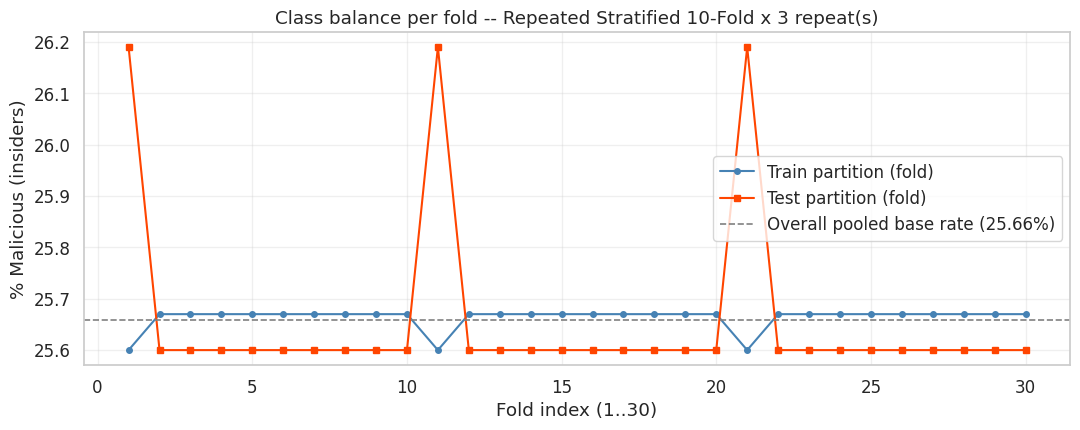

Saved fold_composition.csv | fold_composition.png


In [24]:
# ── 6.2 Fold composition table + plot (class balance, per revision brief) ──
print("Fold composition -- realised class balance per fold (first/last 5 shown):")
print(pd.concat([df_fold_composition.head(5), df_fold_composition.tail(5)]).to_string(index=False))

print(f"\nOverall pooled base rate: {y_all.mean()*100:.2f}% malicious "
     f"({int(y_all.sum())}/{len(y_all)})")
print(f"Test-fold malicious%%  -- min={df_fold_composition['test_malicious_pct'].min():.2f}  "
     f"max={df_fold_composition['test_malicious_pct'].max():.2f}  "
     f"mean={df_fold_composition['test_malicious_pct'].mean():.2f}  "
     f"std={df_fold_composition['test_malicious_pct'].std():.2f}")

df_fold_composition.to_csv('fold_composition.csv', index=False)

fig, ax = plt.subplots(figsize=(11, 4.5))
x = df_fold_composition['fold']
ax.plot(x, df_fold_composition['train_malicious_pct'], marker='o', ms=4,
       label='Train partition (fold)', color='steelblue')
ax.plot(x, df_fold_composition['test_malicious_pct'], marker='s', ms=4,
       label='Test partition (fold)', color='orangered')
ax.axhline(y_all.mean() * 100, color='gray', ls='--', lw=1.2,
          label=f'Overall pooled base rate ({y_all.mean()*100:.2f}%)')
ax.set_xlabel('Fold index (1..%d)' % n_total_folds)
ax.set_ylabel('% Malicious (insiders)')
ax.set_title(f'Class balance per fold -- Repeated Stratified {N_SPLITS_CV}-Fold x {N_REPEATS_CV} repeat(s)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fold_composition.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved fold_composition.csv | fold_composition.png")


### Summary table and heatmap


TABLE -- 30-Fold Repeated CV: Mean +/- Std  [95% Bootstrap CI]  (F1, malicious class)
Mean/Std computed across the 30 individual fold-level F1 scores per architecture.
                           Architecture   Mean    Std  CI_Lower_95  CI_Upper_95  N_folds
           TAN over Features (Chow-Liu) 0.9736 0.0203       0.9663       0.9806       30
                      Semi-Naive (SIND) 0.9655 0.0253       0.9568       0.9746       30
                            Naive Bayes 0.9155 0.0344       0.9025       0.9277       30
     SIND + Latent Structure (Chow-Liu) 0.8853 0.0399       0.8715       0.8999       30
SIND + Latent Structure (HillClimb/BIC) 0.8853 0.0399       0.8715       0.8999       30
            Hierarchical Latent (fixed) 0.8598 0.0302       0.8497       0.8712       30

Saved architecture_cv_summary.csv (all metrics, all architectures, Mean+Std+CI)


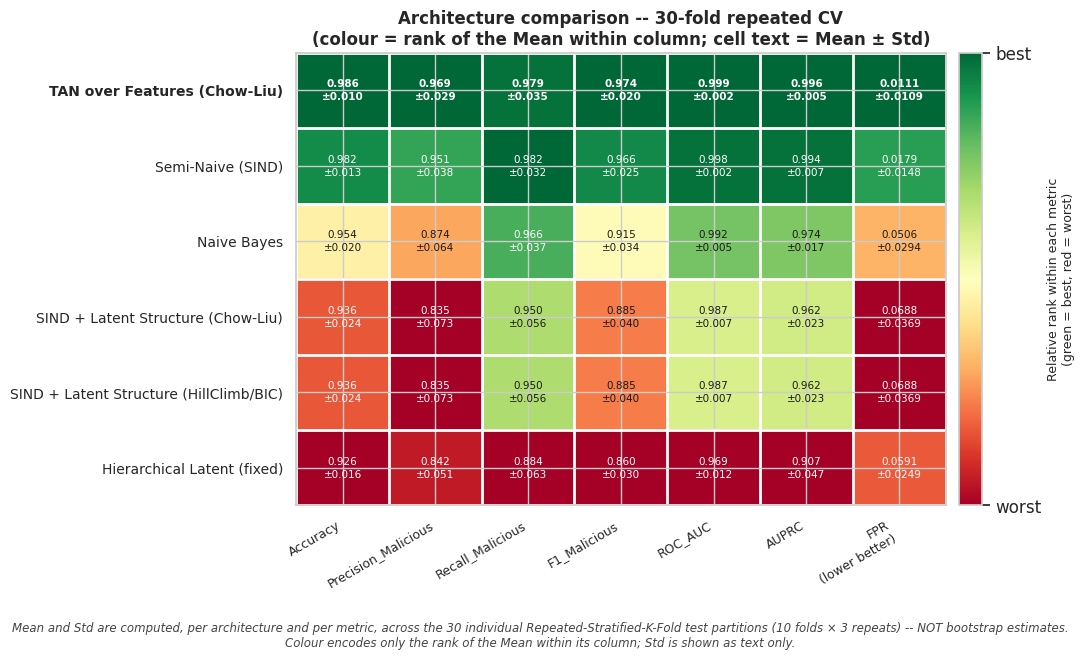

Saved architecture_comparison_heatmap.png

>>> BEST architecture by mean CV F1: TAN-F (TAN over Features (Chow-Liu))  F1=0.9736 <<<
    (This selection drives Sections 8-14: the final single run,
     ablations, and the interpretability graph all use this architecture.)


In [25]:
# ── 6.3 Summary table: mean +/- std + 95% bootstrap CI, per architecture ───
# WHAT Mean/Std ARE, EXACTLY:
#   For each architecture and each metric (F1, Accuracy, FPR, ...), the
#   pipeline computed ONE score per CV fold (e.g. F1 on that fold's held-out
#   test partition) -- that's a list of n_total_folds=30 numbers per
#   (architecture, metric) pair, stored in cv_results[arch_key].
#   Mean = arithmetic mean of those 30 fold-level scores.
#   Std  = population standard deviation (np.std, ddof=0) of the same 30 values.
#   CI_Lower_95 / CI_Upper_95 = a SEPARATE, bootstrap-based 95% interval on
#   the mean (resample the 30 values with replacement N_BOOTSTRAP times,
#   see Section 2.2) -- not derived from Mean/Std directly.
summary_rows = []
for arch_key in ARCHITECTURE_NAMES:
    s = summarize_repeated_results(cv_results[arch_key], n_bootstrap=N_BOOTSTRAP)
    s['Architecture'] = ARCHITECTURE_NAMES[arch_key]
    s['Arch_Key'] = arch_key
    s['N_folds'] = len(cv_results[arch_key])
    summary_rows.append(s)
df_cv_summary = pd.concat(summary_rows).reset_index()

print("="*90)
print(f"TABLE -- {n_total_folds}-Fold Repeated CV: Mean +/- Std  [95% Bootstrap CI]  (F1, malicious class)")
print(f"Mean/Std computed across the {n_total_folds} individual fold-level F1 scores per architecture.")
print("="*90)
f1_table = df_cv_summary[df_cv_summary['Metric'] == 'F1_Malicious'][
    ['Architecture', 'Mean', 'Std', 'CI_Lower_95', 'CI_Upper_95', 'N_folds']
].sort_values('Mean', ascending=False)
print(f1_table.to_string(index=False))

df_cv_summary.to_csv('architecture_cv_summary.csv', index=False)
print("\nSaved architecture_cv_summary.csv (all metrics, all architectures, Mean+Std+CI)")

# ── heatmap across all reported metrics ──────────────────────────────────
metric_keys_heat = ["Accuracy", "Precision_Malicious", "Recall_Malicious",
                    "F1_Malicious", "ROC_AUC", "AUPRC", "FPR"]
LOWER_IS_BETTER = {"FPR"}   # everything else in this list is "higher is better"

heat_mean = df_cv_summary[df_cv_summary['Metric'].isin(metric_keys_heat)].pivot(
    index='Architecture', columns='Metric', values='Mean')
heat_std = df_cv_summary[df_cv_summary['Metric'].isin(metric_keys_heat)].pivot(
    index='Architecture', columns='Metric', values='Std')
heat_mean = heat_mean[metric_keys_heat].loc[f1_table['Architecture']]  # order rows by F1 rank
heat_std  = heat_std[metric_keys_heat].loc[f1_table['Architecture']]

# per-column min-max normalisation of the MEAN (0=worst, 1=best), direction-aware
# -- colour is purely for ranking at a glance; Std is never used for colour,
# only shown as text, since "which architecture is more/less variable" is a
# separate question from "which architecture scores higher".
heat_color = heat_mean.copy().astype(float)
for col in heat_color.columns:
    lo, hi = heat_mean[col].min(), heat_mean[col].max()
    span = (hi - lo) if (hi - lo) > 1e-9 else 1.0
    if col in LOWER_IS_BETTER:
        heat_color[col] = (hi - heat_mean[col]) / span
    else:
        heat_color[col] = (heat_mean[col] - lo) / span

col_labels = [f'{c}\n(lower better)' if c in LOWER_IS_BETTER else c for c in heat_mean.columns]

fig, ax = plt.subplots(figsize=(11, 6.2))
im = ax.imshow(heat_color.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(heat_mean.columns)))
ax.set_xticklabels(col_labels, rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(heat_mean.index)))
ax.set_yticklabels(heat_mean.index, fontsize=10)

best_row_label = f1_table['Architecture'].iloc[0]
for tick, lbl in zip(ax.get_yticklabels(), heat_mean.index):
    if lbl == best_row_label:
        tick.set_fontweight('bold')

ax.set_xticks(np.arange(-0.5, len(heat_mean.columns), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(heat_mean.index), 1), minor=True)
ax.grid(which='minor', color='white', linewidth=2)
ax.tick_params(which='minor', bottom=False, left=False)

# annotate mean AND std together, so it's explicit these are fold-level
# aggregates, not a single point estimate
for i in range(heat_mean.shape[0]):
    for j, col in enumerate(heat_mean.columns):
        mean_v = heat_mean.values[i, j]
        std_v  = heat_std.values[i, j]
        decimals = 4 if col == 'FPR' else 3
        txt = f'{mean_v:.{decimals}f}\n\u00b1{std_v:.{decimals}f}'
        cell_rgb = plt.cm.RdYlGn(heat_color.values[i, j])[:3]
        luminance = 0.299*cell_rgb[0] + 0.587*cell_rgb[1] + 0.114*cell_rgb[2]
        text_color = 'white' if luminance < 0.6 else '#1a1a1a'
        weight = 'bold' if heat_mean.index[i] == best_row_label else 'normal'
        ax.text(j, i, txt, ha='center', va='center', fontsize=7.5,
                color=text_color, fontweight=weight, linespacing=1.4)

cbar = plt.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label('Relative rank within each metric\n(green = best, red = worst)', fontsize=9)
cbar.set_ticks([0, 1]); cbar.set_ticklabels(['worst', 'best'])

ax.set_title(f'Architecture comparison -- {n_total_folds}-fold repeated CV\n'
            f'(colour = rank of the Mean within column; cell text = Mean \u00b1 Std)',
            fontsize=12, fontweight='bold')

# explicit footnote so the source of Mean/Std is unambiguous even if this
# figure is copied out of the notebook on its own
fig.text(0.5, -0.06,
         f'Mean and Std are computed, per architecture and per metric, across the '
         f'{n_total_folds} individual Repeated-Stratified-K-Fold test partitions '
         f'({N_SPLITS_CV} folds \u00d7 {N_REPEATS_CV} repeats) -- NOT bootstrap estimates.\n'
         f'Colour encodes only the rank of the Mean within its column; Std is shown as text only.',
         ha='center', fontsize=8.5, style='italic', color='#444')

plt.tight_layout()
plt.savefig('architecture_comparison_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved architecture_comparison_heatmap.png")

# ── 6.4 Select BEST architecture by mean CV F1 ──────────────────────────────
# Selection happens on the CV result, NOT on the held-out canonical test set
# used later in Section 8 -- this avoids test-set leakage in architecture
# selection (a common methodological pitfall).
f1_means = {k: np.mean([r['F1_Malicious'] for r in cv_results[k]]) for k in ARCHITECTURE_NAMES}
best_arch_key = max(f1_means, key=f1_means.get)
print(f"\n>>> BEST architecture by mean CV F1: {best_arch_key} "
     f"({ARCHITECTURE_NAMES[best_arch_key]})  F1={f1_means[best_arch_key]:.4f} <<<")
print("    (This selection drives Sections 8-14: the final single run,")
print("     ablations, and the interpretability graph all use this architecture.)")

## 7. Statistical Tests — Wilcoxon Signed-Rank

The paired Wilcoxon signed-rank test compares the **best architecture**
(selected in Section 6.4) against **each of the other five**, on the *same*
30 folds (legitimate pairing, since every architecture was evaluated on
identical splits). Reported: two-sided p-value and effect size *r = Z / √N*.

> *p* < 0.05 is considered statistically significant. With N=30 paired
> observations (vs. N=5 or N=10 in earlier iterations of this pipeline),
> the test has meaningfully more power to detect a true difference; it can
> resolve differences as small as needing ~20 of 30 folds to agree in
> direction, versus needing near-unanimous agreement at N=5.


In [26]:
# ── 7.1 Wilcoxon: best architecture vs every other (paired on folds) ───────
n_paired = len(cv_results[best_arch_key])
best_f1s = [r['F1_Malicious'] for r in cv_results[best_arch_key]]

wilcoxon_rows = []
for arch_key in ARCHITECTURE_NAMES:
    if arch_key == best_arch_key:
        continue
    other_f1s = [r['F1_Malicious'] for r in cv_results[arch_key]]
    diffs = np.array(best_f1s) - np.array(other_f1s)
    try:
        if np.all(diffs == 0):
            stat, p, z_val = 0.0, 1.0, 0.0
        else:
            stat, p = wilcoxon(best_f1s, other_f1s, alternative='two-sided')
            z_val = _norm.ppf(1 - p / 2) * np.sign(np.mean(diffs))
        r_eff = abs(z_val) / np.sqrt(n_paired)
    except Exception:
        stat, p, r_eff = np.nan, np.nan, np.nan

    wilcoxon_rows.append({
        'Comparison'          : f'{best_arch_key} vs {arch_key}',
        'Best_F1_mean'        : round(np.mean(best_f1s), 4),
        'Other_F1_mean'       : round(np.mean(other_f1s), 4),
        'Delta_F1'            : round(np.mean(best_f1s) - np.mean(other_f1s), 4),
        'Wilcoxon_stat'       : round(stat, 3) if not np.isnan(stat) else np.nan,
        'p_value'             : round(p, 4) if not np.isnan(p) else np.nan,
        'effect_size_r'       : round(r_eff, 4) if not np.isnan(r_eff) else np.nan,
        'Significant'         : 'YES' if (not np.isnan(p) and p < 0.05) else 'no',
        'N_paired_folds'      : n_paired,
    })

df_wilcoxon = pd.DataFrame(wilcoxon_rows).set_index('Comparison')
print("="*100)
print(f"TABLE -- Wilcoxon Tests: {best_arch_key} ({ARCHITECTURE_NAMES[best_arch_key]}) vs every "
     f"other architecture  (F1, {n_paired} paired folds)")
print("="*100)
print(df_wilcoxon.to_string())

df_wilcoxon.to_csv('wilcoxon_tests.csv')
print("\nSaved wilcoxon_tests.csv")


TABLE -- Wilcoxon Tests: TAN-F (TAN over Features (Chow-Liu)) vs every other architecture  (F1, 30 paired folds)
                  Best_F1_mean  Other_F1_mean  Delta_F1  Wilcoxon_stat  p_value  effect_size_r Significant  N_paired_folds
Comparison                                                                                                                
TAN-F vs NB             0.9736         0.9155    0.0581            0.0   0.0000         0.8732         YES              30
TAN-F vs SNBN           0.9736         0.9655    0.0081           98.0   0.0825         0.3171          no              30
TAN-F vs HL             0.9736         0.8598    0.1138            0.0   0.0000         0.8731         YES              30
TAN-F vs SIND-CL        0.9736         0.8853    0.0883            0.0   0.0000         0.8731         YES              30
TAN-F vs SIND-HC        0.9736         0.8853    0.0883            0.0   0.0000         0.8731         YES              30

Saved wilcoxon_tests.csv


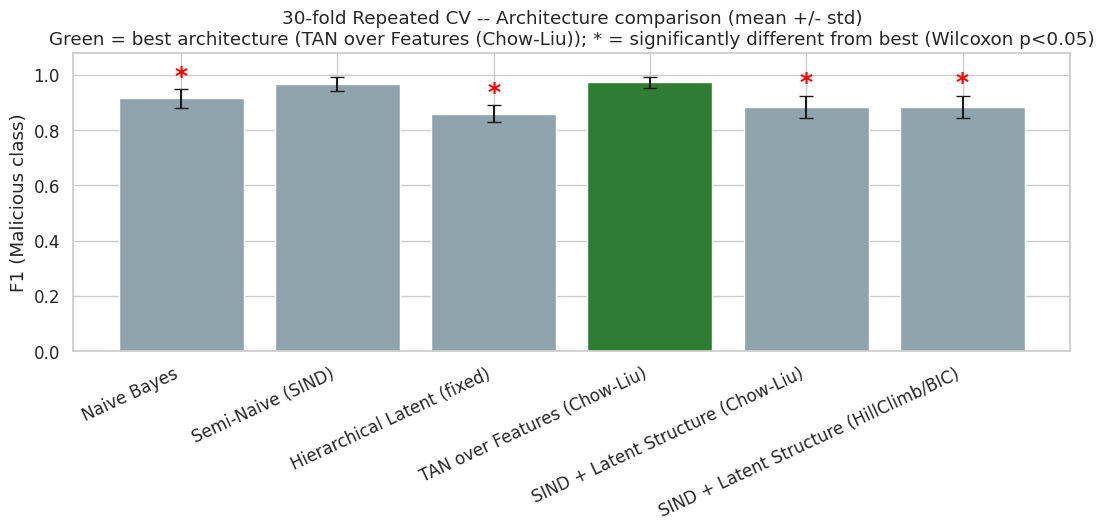

Saved architecture_comparison_f1_significance.png


In [27]:
# ── 7.2 Bar chart with significance markers ─────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5.5))
keys = list(ARCHITECTURE_NAMES.keys())
means = [np.mean([r['F1_Malicious'] for r in cv_results[k]]) for k in keys]
stds  = [np.std([r['F1_Malicious'] for r in cv_results[k]]) for k in keys]
colors = ['#2E7D32' if k == best_arch_key else '#90A4AE' for k in keys]

ax.bar([ARCHITECTURE_NAMES[k] for k in keys], means, yerr=stds, color=colors, capsize=5,
      error_kw={'lw': 1.5})
ax.set_ylabel('F1 (Malicious class)')
ax.set_ylim(0, 1.08)
ax.set_title(f'{n_total_folds}-fold Repeated CV -- Architecture comparison (mean +/- std)\n'
            f'Green = best architecture ({ARCHITECTURE_NAMES[best_arch_key]}); '
            f'* = significantly different from best (Wilcoxon p<0.05)')
plt.xticks(rotation=25, ha='right')

for i, k in enumerate(keys):
    if k == best_arch_key:
        continue
    comp = f'{best_arch_key} vs {k}'
    if comp in df_wilcoxon.index and df_wilcoxon.loc[comp, 'Significant'] == 'YES':
        ax.text(i, means[i] + stds[i] + 0.02, '*', ha='center', fontsize=18, color='red',
               fontweight='bold')

plt.tight_layout()
plt.savefig('architecture_comparison_f1_significance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved architecture_comparison_f1_significance.png")


## 8. Best-Architecture Selection & Final Canonical Run

The architecture selected in Section 6.4 is now trained on the **original,
unpooled Train2/Val/Test split** (the harder, more realistic scenario with
the train/test class-distribution mismatch noted in Section 1), with the
**full four-method threshold comparison** (Grid-F1, Youden's J, Platt,
Isotonic) — this reproduces, for the winning architecture, exactly the kind
of single-run table (`Table III`-equivalent) that the original SIND pipeline
produced for its one architecture, now automatically pointed at whichever
architecture actually won the comparison.


Best architecture : TAN-F (TAN over Features (Chow-Liu))
Edges             : 47
ML-learned edges  : [('device_active_days', 'file_pdf_files_accessed'), ('device_active_days', 'logon_total_logons_day'), ('device_device_events_total', 'device_offhour_device_ratio'), ('device_device_events_total', 'device_unique_pcs_used'), ('device_max_daily_device_events', 'device_offhour_device_count'), ('device_offhour_device_count', 'device_usb_connects'), ('device_std_daily_device_events', 'device_max_daily_device_events'), ('device_std_daily_device_events', 'device_mean_daily_device_events'), ('device_usb_connects', 'device_active_days'), ('device_usb_connects', 'device_device_events_total'), ('email_email_unique_to', 'email_email_mean_text_len'), ('email_email_unique_to', 'http_unique_urls_visited'), ('email_n_email', 'email_email_total_attachments'), ('email_n_email', 'email_email_unique_to'), ('file_pdf_files_accessed', 'file_exe_files_accessed'), ('logon_logon_to_logoff_ratio', 'email_email_uni

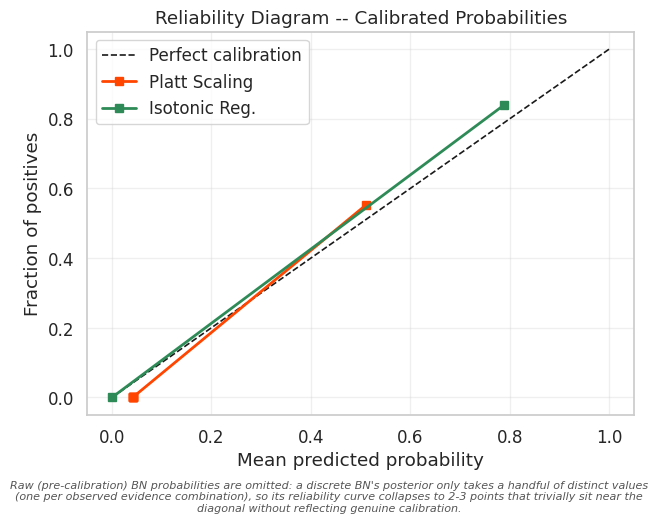

                              Precision_Malicious  Recall_Malicious  F1_Malicious     FPR  ROC_AUC   AUPRC
Method                                                                                                    
Grid-F1 (t=0.05)                           0.9091            0.9524        0.9302  0.0072   0.9991  0.9901
Youden's J (t=0.73, J=0.992)               0.9524            0.9524        0.9524  0.0036   0.9991  0.9901
Platt Scaling (t=0.50)                     0.9524            0.9524        0.9524  0.0036   0.9991  0.9901
Isotonic Regression (t=0.50)               0.9524            0.9524        0.9524  0.0036   0.9989  0.9810

  -> Best threshold method by F1: Youden's J (t=0.73, J=0.992)

Final single-run metrics (canonical Train2/Val/Test, best architecture):
  TP                  : 20
  FP                  : 1
  TN                  : 278
  FN                  : 1
  Threshold           : 0.73
  Accuracy            : 0.9933
  Precision_Malicious : 0.9524
  Recall_Malicious    

In [32]:
# ── 8.1 Train the BEST architecture on canonical Train2/Val, evaluate on Test
pp_final = preprocess_pipeline(X_tr2, X_val, X_test, y_tr2, apply_smote=False,
                               random_state=RANDOM_STATE)
train_df_final = pp_final['X_tr'].copy()
train_df_final['label'] = pp_final['y_tr'].values
for c in train_df_final.columns:
    train_df_final[c] = train_df_final[c].astype(int)

edges_best, learned_best, cols_best = build_architecture(best_arch_key, pp_final, train_df_final)
model_best, infer_best, tr_best = train_bn(edges_best, train_df_final, estimator='MAP',
                                           prior_type='BDeu', ess=BN_ESS_DEFAULT)

print(f"Best architecture : {best_arch_key} ({ARCHITECTURE_NAMES[best_arch_key]})")
print(f"Edges             : {len(edges_best)}")
if learned_best is not None:
    print(f"ML-learned edges  : {learned_best}")
print(f"Training time     : {tr_best:.3f}s")

val_prob_best, _, cache_best = bn_predict_proba(infer_best, pp_final['X_va'], cols_best)
test_prob_best, inf_t_best, _ = bn_predict_proba(infer_best, pp_final['X_te'], cols_best, cache=cache_best)

print("\n-- Threshold Method Comparison (evaluated on canonical test set) --")
df_thresh_cmp, best_method, cal_platt, cal_iso = compare_threshold_methods(
    y_test, y_val, val_prob_best, test_prob_best)
display_cols = ['Precision_Malicious', 'Recall_Malicious', 'F1_Malicious', 'FPR', 'ROC_AUC', 'AUPRC']
print(df_thresh_cmp[display_cols].to_string())
print(f"\n  -> Best threshold method by F1: {best_method}")

best_t_final = df_thresh_cmp.loc[best_method, 'Threshold']
if 'Platt' in best_method:
    test_prob_final = cal_platt
elif 'Isotonic' in best_method:
    test_prob_final = cal_iso
else:
    test_prob_final = test_prob_best

y_pred_final = (test_prob_final >= best_t_final).astype(int)
metrics_final = compute_metrics_from_predictions(y_test, y_pred_final, test_prob_final,
                                                  threshold=best_t_final)
metrics_final.update({
    'Model'            : f'{best_arch_key} ({ARCHITECTURE_NAMES[best_arch_key]})',
    'Threshold_Method' : best_method,
    'Training_Time_s'  : round(tr_best, 4),
    'Inference_Time_s' : round(inf_t_best, 4),
})
print(f"\nFinal single-run metrics (canonical Train2/Val/Test, best architecture):")
for k, v in metrics_final.items():
    print(f"  {k:20s}: {v}")

df_final_single = pd.DataFrame([metrics_final]).set_index('Model')
df_final_single.to_csv('table_best_architecture_single_run.csv')
print("\nSaved table_best_architecture_single_run.csv")


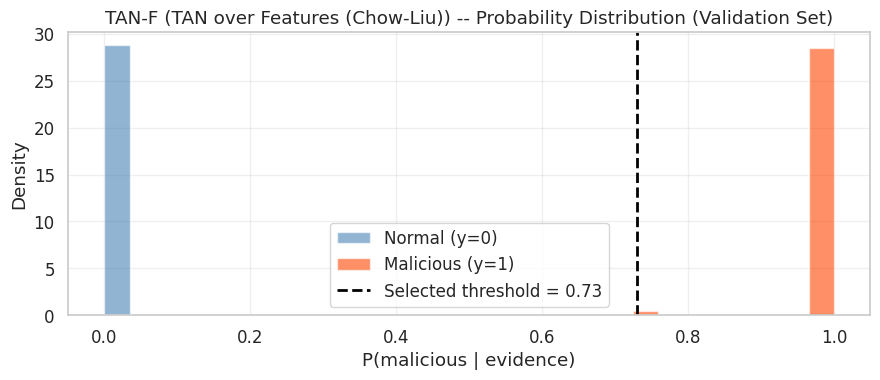

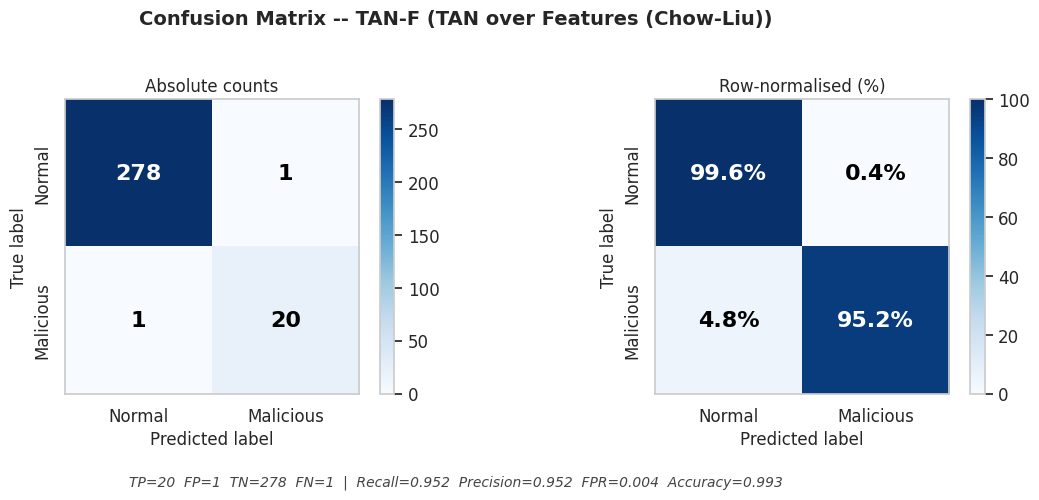

Saved prob_distribution_best.png | confusion_matrix_best.png


In [33]:
# ── 8.2 Probability distribution + confusion matrix for the final run ──────
def plot_prob_histogram(y_val_, val_prob_, best_threshold, model_name='Best architecture', save_path=None):
    fig, ax = plt.subplots(figsize=(9, 4))
    bins = np.linspace(0, 1, 30)
    ax.hist(val_prob_[y_val_ == 0], bins=bins, alpha=0.6, color='steelblue',
           label='Normal (y=0)', density=True)
    ax.hist(val_prob_[y_val_ == 1], bins=bins, alpha=0.6, color='orangered',
           label='Malicious (y=1)', density=True)
    ax.axvline(best_threshold, color='black', ls='--', lw=2,
              label=f'Selected threshold = {best_threshold:.2f}')
    ax.set_xlabel('P(malicious | evidence)'); ax.set_ylabel('Density')
    ax.set_title(f'{model_name} -- Probability Distribution (Validation Set)')
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return fig

plot_prob_histogram(y_val, val_prob_best, best_threshold=best_t_final,
                    model_name=f'{best_arch_key} ({ARCHITECTURE_NAMES[best_arch_key]})',
                    save_path='prob_distribution_best.png')


def plot_confusion_matrix(y_true, y_pred, model_name="Best architecture",
                          class_names=["Normal", "Malicious"], save_path=None):
    cm_ = confusion_matrix(y_true, y_pred, labels=[0, 1])
    cm_pct = cm_.astype(float) / cm_.sum(axis=1, keepdims=True) * 100

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    for ax, data, fmt, title, vmax in [
        (axes[0], cm_,     'd',   'Absolute counts',    cm_.max()),
        (axes[1], cm_pct,  '.1f', 'Row-normalised (%)', 100),
    ]:
        im = ax.imshow(data, cmap='Blues', vmin=0, vmax=vmax)
        ax.grid(False)
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
        ax.set_xticklabels(class_names, fontsize=12)
        ax.set_yticklabels(class_names, fontsize=12, rotation=90, va='center')
        ax.set_xlabel('Predicted label', fontsize=12)
        ax.set_ylabel('True label', fontsize=12)
        ax.set_title(title, fontsize=12)
        thresh = vmax / 2
        for i in range(2):
            for j in range(2):
                val = data[i, j]
                color = 'white' if val > thresh else 'black'
                label = f'{int(val)}' if fmt == 'd' else f'{val:.1f}%'
                ax.text(j, i, label, ha='center', va='center', fontsize=16,
                       fontweight='bold', color=color)

    fig.suptitle(f'Confusion Matrix -- {model_name}', fontsize=14, fontweight='bold', y=1.02)
    tn, fp, fn, tp = cm_.ravel()
    stats = (f"TP={tp}  FP={fp}  TN={tn}  FN={fn}  |  "
            f"Recall={tp/(tp+fn):.3f}  Precision={tp/(tp+fp):.3f}  "
            f"FPR={fp/(fp+tn):.3f}  Accuracy={(tp+tn)/(tp+tn+fp+fn):.3f}")
    fig.text(0.5, -0.04, stats, ha='center', fontsize=10, style='italic', color='#444')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return fig

plot_confusion_matrix(y_test, y_pred_final,
                      model_name=f'{best_arch_key} ({ARCHITECTURE_NAMES[best_arch_key]})',
                      save_path='confusion_matrix_best.png')
print("Saved prob_distribution_best.png | confusion_matrix_best.png")


## 9. SMOTE Ablation

Compares the **best architecture** with vs. without SMOTE oversampling on
the training partition, using `N_REPEATS_CV`-scale repeated runs over
random Train/Val splits of `X_train`, evaluated on the fixed canonical
`X_test`. As in the original pipeline, this quantifies whether synthetic
oversampling of the (already not severely imbalanced, ~31.5%) training data
helps or hurts the discretised-feature Bayesian setting.



--- TAN-F + SMOTE ---
  run 1: F1=0.9524    run 2: F1=0.9048    run 3: F1=0.9545    run 4: F1=0.9767    run 5: F1=0.9524    run 6: F1=0.9545    run 7: F1=0.9268    run 8: F1=0.9524    run 9: F1=0.8718    run 10: F1=0.9048    run 11: F1=0.9545    run 12: F1=0.9545    run 13: F1=0.9302    run 14: F1=0.9048    run 15: F1=0.9545    run 16: F1=0.9302    run 17: F1=0.9767    run 18: F1=0.9048    run 19: F1=0.9767    run 20: F1=0.9545    run 21: F1=0.9524    run 22: F1=0.9048    run 23: F1=0.9302    run 24: F1=0.9767    run 25: F1=0.9767    run 26: F1=0.9524    run 27: F1=0.9767    run 28: F1=0.9048    run 29: F1=0.9302    run 30: F1=0.9524  

--- TAN-F - SMOTE ---
  run 1: F1=0.9302    run 2: F1=0.9767    run 3: F1=0.9767    run 4: F1=0.9767    run 5: F1=0.9524    run 6: F1=0.9767    run 7: F1=0.9048    run 8: F1=0.9302    run 9: F1=0.9302    run 10: F1=0.9545    run 11: F1=0.9545    run 12: F1=0.9302    run 13: F1=0.9767    run 14: F1=0.9000    run 15: F1=0.9302    run 16: F1=0.9524    run

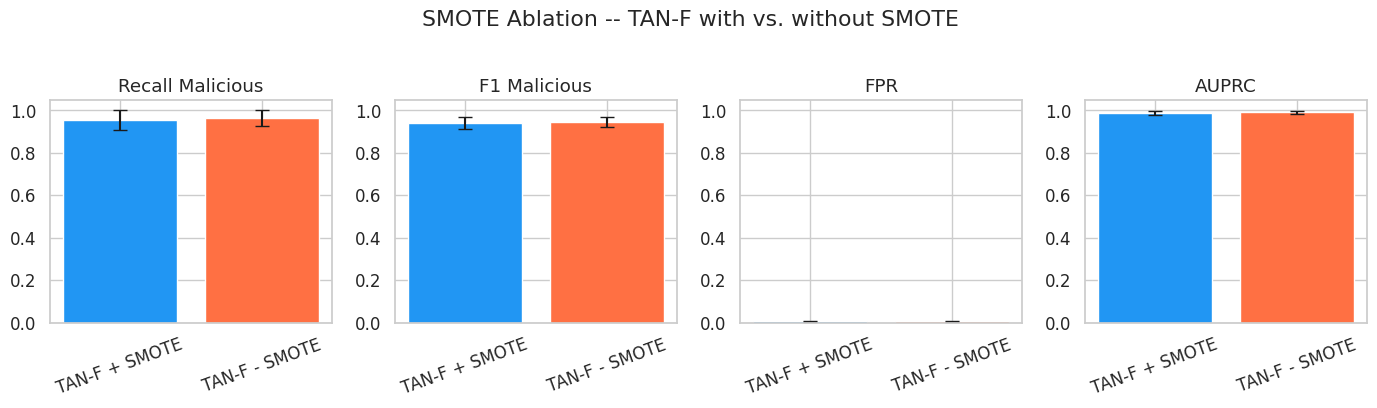

Saved smote_ablation.png


In [35]:
# ── 9.1 Run best architecture with and without SMOTE ───────────────────────
N_RUNS_ABLATION = 30   # independent Train/Val re-splits of X_train
ablation_results = {}

for use_smote in [True, False]:
    label = f'{best_arch_key} + SMOTE' if use_smote else f'{best_arch_key} - SMOTE'
    print(f"\n--- {label} ---")
    run_results = []
    for run in range(N_RUNS_ABLATION):
        seed = RANDOM_STATE + run
        X_r, X_v, y_r, y_v = train_test_split(
            X_train, y_train, test_size=VAL_SIZE, stratify=y_train, random_state=seed)
        pp_r = preprocess_pipeline(X_r, X_v, X_test, y_r, apply_smote=use_smote, random_state=seed)
        train_df_r = pp_r['X_tr'].copy(); train_df_r['label'] = pp_r['y_tr'].values
        for c in train_df_r.columns:
            train_df_r[c] = train_df_r[c].astype(int)
        edges_r, _, cols_r = build_architecture(best_arch_key, pp_r, train_df_r)
        _, infer_r, _ = train_bn(edges_r, train_df_r, estimator='MAP')

        vp, _, cache_r = bn_predict_proba(infer_r, pp_r['X_va'], cols_r)
        best_t_r, _ = calibrate_threshold(y_v, vp)
        tp_r, _, _ = bn_predict_proba(infer_r, pp_r['X_te'], cols_r, cache=cache_r)
        yp = (tp_r >= best_t_r).astype(int)
        m = compute_metrics_from_predictions(y_test, yp, tp_r, threshold=best_t_r)
        run_results.append(m)
        print(f"  run {run+1}: F1={m['F1_Malicious']:.4f}", end='  ')
    ablation_results[label] = run_results
    print()

# ── 9.2 Summary table ────────────────────────────────────────────────────────
ablation_rows = []
for label, res_list in ablation_results.items():
    s = summarize_repeated_results(res_list, n_bootstrap=N_BOOTSTRAP)
    s.insert(0, 'Model', label)
    ablation_rows.append(s)
df_ablation = pd.concat(ablation_rows).reset_index()
key_metrics = ['Recall_Malicious', 'F1_Malicious', 'FPR', 'AUPRC']
pivot = df_ablation[df_ablation['Metric'].isin(key_metrics)].pivot(
    index='Metric', columns='Model', values='Mean')
print("\n" + "="*60)
print(f"TABLE -- SMOTE Ablation ({best_arch_key}, mean over {N_RUNS_ABLATION} runs)")
print("="*60)
print(pivot.to_string())
df_ablation.to_csv('smote_ablation.csv', index=False)
print("\nSaved smote_ablation.csv")

# ── 9.3 Bar chart ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(key_metrics), figsize=(14, 4), sharey=False)
for ax, metric in zip(axes, key_metrics):
    vals, stds, lbls = [], [], []
    for label, res_list in ablation_results.items():
        v = [r[metric] for r in res_list]
        vals.append(np.mean(v)); stds.append(np.std(v)); lbls.append(label)
    ax.bar(lbls, vals, yerr=stds, color=['#2196F3', '#FF7043'], capsize=5)
    ax.set_title(metric.replace('_', ' '))
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=20)
plt.suptitle(f'SMOTE Ablation -- {best_arch_key} with vs. without SMOTE', y=1.02)
plt.tight_layout()
plt.savefig('smote_ablation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved smote_ablation.png")


## 10. Imbalance Sensitivity

Tests the **best architecture**'s performance when the malicious class is
subsampled to simulate realistic insider-threat ratios (1%-30% of the
training pool). The normal class is kept at full size; the malicious class
is reduced — reflecting the real-world scenario where genuinely malicious
users are rare. SMOTE is switched on automatically once the target minority
fraction drops below 5%, matching the original pipeline's logic.


Imbalance sensitivity analysis (subsampling MALICIOUS class)...
  Normal samples (fixed): 651  |  Max malicious available: 300

  Target    1% -> n_mal=  6  actual=0.9%  total=657
  Target    2% -> n_mal= 13  actual=2.0%  total=664
  Target    5% -> n_mal= 34  actual=5.0%  total=685
  Target   10% -> n_mal= 72  actual=10.0%  total=723
  Target   20% -> n_mal=162  actual=19.9%  total=813
  Target   30% -> n_mal=279  actual=30.0%  total=930


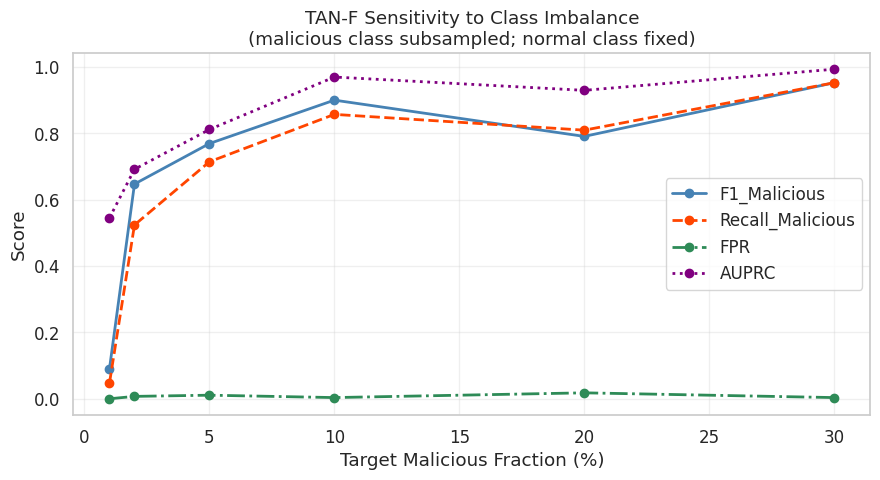


Saved imbalance_sensitivity.csv | imbalance_sensitivity.png
 target_ratio  actual_ratio  n_mal_train  F1_Malicious  Recall_Malicious    FPR  AUPRC
         0.01        0.0091            6        0.0909            0.0476 0.0000 0.5451
         0.02        0.0196           13        0.6471            0.5238 0.0072 0.6916
         0.05        0.0496           34        0.7692            0.7143 0.0108 0.8116
         0.10        0.0996           72        0.9000            0.8571 0.0036 0.9696
         0.20        0.1993          162        0.7907            0.8095 0.0179 0.9295
         0.30        0.3000          279        0.9524            0.9524 0.0036 0.9932


In [36]:
# ── 10.1 Sensitivity experiment (malicious class subsampled) ───────────────
print("Imbalance sensitivity analysis (subsampling MALICIOUS class)...")
imbalance_rows = []

X_mal, y_mal   = X_train[y_train == 1].copy(), y_train[y_train == 1].copy()
X_norm, y_norm = X_train[y_train == 0].copy(), y_train[y_train == 0].copy()
n_norm = len(X_norm)
rng_imb = np.random.default_rng(RANDOM_STATE)

print(f"  Normal samples (fixed): {n_norm}  |  Max malicious available: {len(X_mal)}\n")

for ratio in IMBALANCE_RATIOS:
    n_mal_target = max(int(n_norm * ratio / (1.0 - ratio)), 5)
    n_mal_target = min(n_mal_target, len(X_mal))
    actual_ratio = n_mal_target / (n_norm + n_mal_target)

    idx = rng_imb.choice(len(X_mal), size=n_mal_target, replace=False)
    X_sub = pd.concat([X_norm, X_mal.iloc[idx]]).reset_index(drop=True)
    y_sub = pd.concat([y_norm, y_mal.iloc[idx]]).reset_index(drop=True)

    print(f"  Target {ratio*100:4.0f}% -> n_mal={n_mal_target:3d}  "
         f"actual={actual_ratio*100:.1f}%  total={len(X_sub)}")

    try:
        X_r, X_v, y_r, y_v = train_test_split(
            X_sub, y_sub, test_size=VAL_SIZE, stratify=y_sub, random_state=RANDOM_STATE)
        use_smote = actual_ratio < 0.05
        pp_r = preprocess_pipeline(X_r, X_v, X_test, y_r, apply_smote=use_smote)
        train_df_r = pp_r['X_tr'].copy(); train_df_r['label'] = pp_r['y_tr'].values
        for c in train_df_r.columns:
            train_df_r[c] = train_df_r[c].astype(int)
        edges_r, _, cols_r = build_architecture(best_arch_key, pp_r, train_df_r)
        _, infer_r, _ = train_bn(edges_r, train_df_r, estimator='MAP')

        vp, _, cache_r = bn_predict_proba(infer_r, pp_r['X_va'], cols_r)
        best_t, _ = threshold_youden(y_v, vp)
        best_t = float(np.clip(best_t, 0.01, 0.99))
        tp_r, _, _ = bn_predict_proba(infer_r, pp_r['X_te'], cols_r, cache=cache_r)
        yp = (tp_r >= best_t).astype(int)
        m = compute_metrics_from_predictions(y_test, yp, tp_r, threshold=best_t)
        m.update({'target_ratio': ratio, 'actual_ratio': round(actual_ratio, 4),
                  'n_mal_train': n_mal_target, 'smote_used': use_smote})
    except Exception as e:
        print(f"    Failed: {e}")
        m = {'target_ratio': ratio, 'actual_ratio': round(actual_ratio, 4), 'error': str(e)}
    imbalance_rows.append(m)

df_imbalance = pd.DataFrame(imbalance_rows)
df_imbalance.to_csv('imbalance_sensitivity.csv', index=False)

# ── 10.2 Line chart ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
ratios_pct = [r * 100 for r in df_imbalance['target_ratio']]
for metric, color, style in [
    ('F1_Malicious',     'steelblue', '-'),
    ('Recall_Malicious', 'orangered', '--'),
    ('FPR',              'seagreen',  '-.'),
    ('AUPRC',            'purple',    ':'),
]:
    if metric in df_imbalance.columns:
        ax.plot(ratios_pct, df_imbalance[metric], marker='o', label=metric, color=color, ls=style, lw=2)
ax.set_xlabel('Target Malicious Fraction (%)'); ax.set_ylabel('Score')
ax.set_title(f'{best_arch_key} Sensitivity to Class Imbalance\n'
            '(malicious class subsampled; normal class fixed)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('imbalance_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved imbalance_sensitivity.csv | imbalance_sensitivity.png")
print(df_imbalance[['target_ratio', 'actual_ratio', 'n_mal_train',
                    'F1_Malicious', 'Recall_Malicious', 'FPR', 'AUPRC']].to_string(index=False))


## 11. CPT Stability via Bootstrap

`N_BOOT_CPT` bootstrap resamples of the canonical training set. For each
resample, the **best architecture** is retrained and the CPD values for its
`TOP_N_CPT_NODES` highest-MI nodes are recorded. Reports mean/max standard
deviation of each CPT entry across resamples — a low std indicates the
learned conditional probabilities are stable and not an artefact of the
particular training sample.


Structure fixed for CPT-stability bootstrap (47 edges, learned once on the full training set).
Analysing CPT stability for 10 nodes: ['device_max_daily_device_events', 'device_mean_daily_device_events', 'device_active_days', 'device_device_events_total', 'device_usb_connects', 'device_offhour_device_count', 'device_offhour_device_ratio', 'device_std_daily_device_events', 'logon_total_logoffs_day', 'email_n_email']
  Bootstrap 20/100
  Bootstrap 40/100
  Bootstrap 60/100
  Bootstrap 80/100
  Bootstrap 100/100

CPT Stability (Bootstrap, N=100, architecture=TAN-F, 10 nodes, structure held fixed)
  # 1  device_max_daily_device_events       mean_std=0.0455  max_std=0.2023  (N=100)
  # 2  device_mean_daily_device_events      mean_std=0.0518  max_std=0.2023  (N=100)
  # 3  device_active_days                   mean_std=0.0279  max_std=0.1015  (N=100)
  # 4  device_device_events_total           mean_std=0.0052  max_std=0.0288  (N=100)
  # 5  device_usb_connects                  mean_std=0.0044 

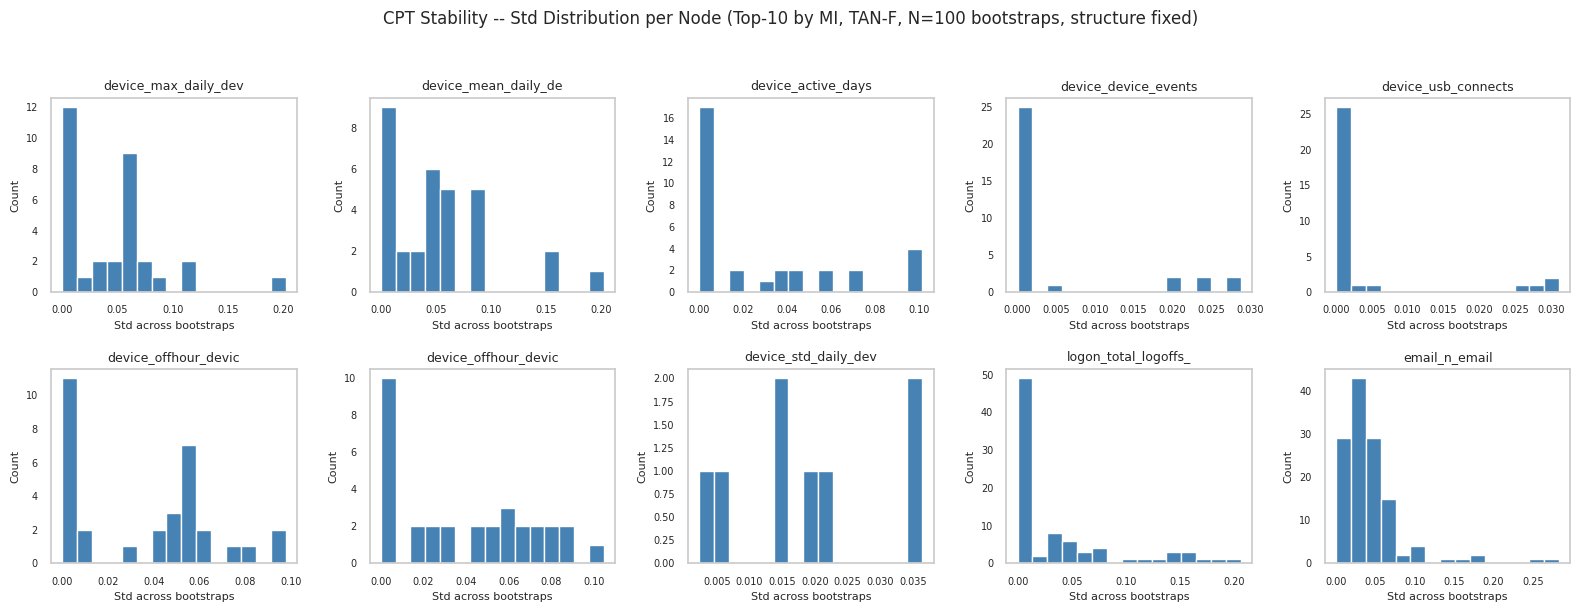

Saved cpt_stability.png


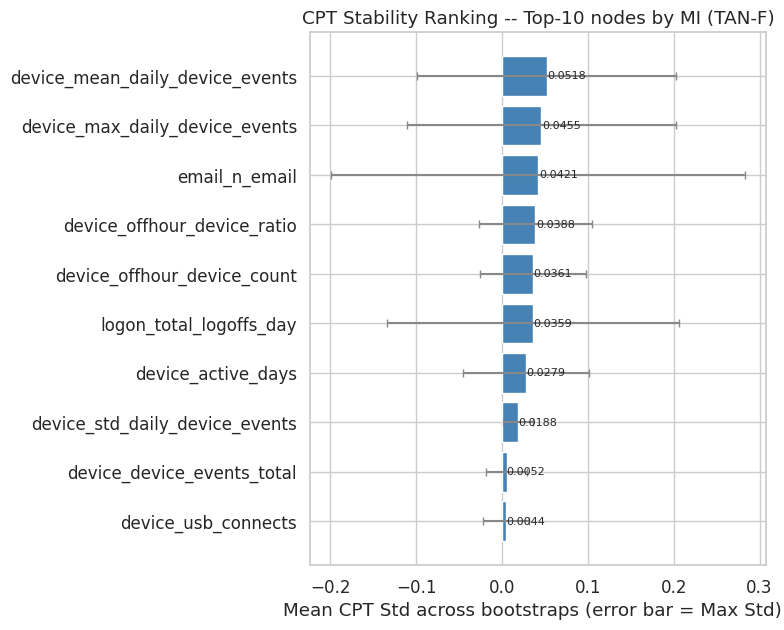

Saved cpt_stability_ranking.png


In [41]:
# ── 11.1 Bootstrap loop for CPT stability ───────────────────────────────────
X_tr_nm   = X_tr2.drop(columns=['user'], errors='ignore')
mi_scores_cpt = mutual_info_classif(X_tr_nm[TOP_FEATURES], y_tr2,
                                    discrete_features='auto', random_state=RANDOM_STATE)
mi_series_cpt = pd.Series(mi_scores_cpt, index=TOP_FEATURES).sort_values(ascending=False)

pp_cpt = preprocess_pipeline(X_tr2, None, X_test, y_tr2, apply_smote=False, random_state=RANDOM_STATE)
train_df_cpt_full = pp_cpt['X_tr'].copy(); train_df_cpt_full['label'] = pp_cpt['y_tr'].values
for c in train_df_cpt_full.columns:
    train_df_cpt_full[c] = train_df_cpt_full[c].astype(int)

# Structure is learned ONCE, on the full original training data, and then
# HELD FIXED for every bootstrap resample below.
#
# Why: for architectures with ML-learned structure (TAN-F, SIND-CL, SIND-HC),
# re-running build_architecture() inside the bootstrap loop would re-learn
# the Chow-Liu tree / HillClimb edges on EACH resample. Because structure
# learning depends on the mutual information of that specific resample, a
# node's parent set can change from one bootstrap iteration to the next --
# which changes its CPD's shape (cardinality of the parent set) and breaks
# np.stack() when we try to compare CPDs across iterations (this is exactly
# what caused the ValueError: 'all input arrays must have the same shape').
#
# More importantly, mixing "parameter uncertainty" (how much do the
# probabilities move when the training sample changes) with "structure
# uncertainty" (does the graph topology itself change) answers a different,
# muddled question. Bootstrap CPT-stability is meant to isolate the former:
# fix the graph, vary the data, see how much the CPD entries move.
edges_cpt_probe, _, cols_cpt_probe = build_architecture(best_arch_key, pp_cpt, train_df_cpt_full)
print(f"Structure fixed for CPT-stability bootstrap ({len(edges_cpt_probe)} edges, "
     f"learned once on the full training set).")

latent_mi_cpt = {}
for lname in pp_cpt['latent_names']:
    latent_mi_cpt[lname] = mutual_info_classif(
        pp_cpt['X_tr'][[lname]], pp_cpt['y_tr'], discrete_features=True,
        random_state=RANDOM_STATE)[0]
mi_full_cpt = pd.concat([mi_series_cpt, pd.Series(latent_mi_cpt)]).sort_values(ascending=False)
top_nodes = [n for n in mi_full_cpt.index if n in cols_cpt_probe][:TOP_N_CPT_NODES]
print(f"Analysing CPT stability for {len(top_nodes)} nodes: {top_nodes}")

cpd_store = defaultdict(list)
rng_boot = np.random.default_rng(RANDOM_STATE)

for b in range(N_BOOT_CPT):
    idx = rng_boot.choice(len(pp_cpt['X_tr']), size=len(pp_cpt['X_tr']), replace=True)
    X_boot = pp_cpt['X_tr'].iloc[idx].reset_index(drop=True)
    y_boot = pp_cpt['y_tr'].iloc[idx].reset_index(drop=True)
    train_df_b = X_boot.copy(); train_df_b['label'] = y_boot.values
    for c in train_df_b.columns:
        train_df_b[c] = train_df_b[c].astype(int)

    # Reuse the FIXED structure (edges_cpt_probe) -- only parameters are
    # refit on the bootstrap resample. No structure learning happens here.
    model_b = DiscreteBayesianNetwork(edges_cpt_probe)
    try:
        model_b.fit(train_df_b, estimator=DiscreteBayesianEstimator(
            prior_type='BDeu', equivalent_sample_size=BN_ESS_DEFAULT))
        for node in top_nodes:
            cpd = model_b.get_cpds(node)
            if cpd is not None:
                cpd_store[node].append(cpd.values.copy())
    except Exception as e:
        print(f"  [WARN] bootstrap {b+1} fit failed: {e}")

    if (b + 1) % 20 == 0:
        print(f"  Bootstrap {b+1}/{N_BOOT_CPT}")

# ── 11.2 Summary ─────────────────────────────────────────────────────────────
cpt_summary_rows = []
print("\n" + "="*60)
print(f"CPT Stability (Bootstrap, N={N_BOOT_CPT}, architecture={best_arch_key}, "
     f"{len(top_nodes)} nodes, structure held fixed)")
print("="*60)
for rank, node in enumerate(top_nodes, start=1):
    if node not in cpd_store or len(cpd_store[node]) == 0:
        continue
    # safety net: with structure now fixed this should never trigger, but
    # guard anyway in case a bootstrap resample dropped a rare parent state
    # entirely (pgmpy can then produce a differently-shaped CPD for that
    # one iteration) -- skip mismatched shapes rather than crash the loop.
    shapes = {arr.shape for arr in cpd_store[node]}
    if len(shapes) > 1:
        common_shape = max(shapes, key=lambda s: sum(1 for a in cpd_store[node] if a.shape == s))
        n_dropped = sum(1 for a in cpd_store[node] if a.shape != common_shape)
        print(f"  [WARN] {node}: {n_dropped}/{len(cpd_store[node])} bootstrap CPDs had an "
             f"unexpected shape (likely a rare parent state missing from that resample) -- excluded.")
        cpd_list = [a for a in cpd_store[node] if a.shape == common_shape]
    else:
        cpd_list = cpd_store[node]

    stack = np.stack(cpd_list)
    mean_std = stack.std(axis=0).mean()
    max_std  = stack.std(axis=0).max()
    print(f"  #{rank:2d}  {node:35s}  mean_std={mean_std:.4f}  max_std={max_std:.4f}  "
         f"(N={len(cpd_list)})")
    cpt_summary_rows.append({'Rank_by_MI': rank, 'Node': node,
                             'MI': round(mi_full_cpt.get(node, 0.0), 4),
                             'Mean_CPT_Std': round(mean_std, 4),
                             'Max_CPT_Std': round(max_std, 4), 'N_Bootstraps': len(cpd_list)})

df_cpt = pd.DataFrame(cpt_summary_rows)
df_cpt.to_csv('cpt_stability.csv', index=False)
print("\nSaved cpt_stability.csv")

# ── 11.3 Per-node histograms (grid layout, scales to any N) ─────────────────
n_nodes = len(top_nodes)
n_cols  = min(5, n_nodes)
n_rows  = int(np.ceil(n_nodes / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 3.0 * n_rows))
axes = np.atleast_1d(axes).reshape(-1)

for ax, node in zip(axes, top_nodes):
    if node not in cpd_store or len(cpd_store[node]) == 0:
        ax.set_title(f'{node}\n(no data)'); ax.axis('off'); continue
    shapes = {arr.shape for arr in cpd_store[node]}
    common_shape = max(shapes, key=lambda s: sum(1 for a in cpd_store[node] if a.shape == s))
    cpd_list = [a for a in cpd_store[node] if a.shape == common_shape]
    stds = np.stack(cpd_list).std(axis=0).flatten()
    ax.hist(stds, bins=15, color='steelblue', edgecolor='white')
    ax.grid(False)
    ax.set_title(node[:20], fontsize=9)
    ax.set_xlabel('Std across bootstraps', fontsize=8)
    ax.set_ylabel('Count', fontsize=8)
    ax.tick_params(labelsize=7)

for ax in axes[n_nodes:]:
    ax.axis('off')

fig.suptitle(f'CPT Stability -- Std Distribution per Node (Top-{n_nodes} by MI, '
            f'{best_arch_key}, N={N_BOOT_CPT} bootstraps, structure fixed)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('cpt_stability.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved cpt_stability.png")

# ── 11.4 Summary bar chart -- compare all N nodes at a glance ───────────────
df_cpt_sorted = df_cpt.sort_values('Mean_CPT_Std', ascending=True)

fig, ax = plt.subplots(figsize=(8, 0.5 * len(df_cpt_sorted) + 1.5))
bars = ax.barh(df_cpt_sorted['Node'], df_cpt_sorted['Mean_CPT_Std'],
               xerr=(df_cpt_sorted['Max_CPT_Std'] - df_cpt_sorted['Mean_CPT_Std']),
               color='steelblue', ecolor='#888', capsize=3)
ax.set_xlabel('Mean CPT Std across bootstraps (error bar = Max Std)  ')
ax.set_title(f'CPT Stability Ranking -- Top-{n_nodes} nodes by MI ({best_arch_key})')
for bar, val in zip(bars, df_cpt_sorted['Mean_CPT_Std']):
    ax.text(bar.get_width() * 1.02, bar.get_y() + bar.get_height() / 2,
           f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('cpt_stability_ranking.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved cpt_stability_ranking.png")

## 12. MAP vs MLE Analysis

Compares Maximum Likelihood Estimation (MLE) against Maximum A Posteriori
(MAP) with a BDeu prior at different equivalent sample sizes (ESS), for the
**best architecture**. A higher ESS means stronger regularisation, which is
particularly relevant for rare malicious-behaviour states with few training
examples.


MAP vs MLE experiment (TAN-F)
--------------------------------------------------
  MLE... F1=0.8333  AUPRC=0.8162
  MAP(BDeu=1)... F1=0.9048  AUPRC=0.9838
  MAP(BDeu=5)... F1=0.9524  AUPRC=0.9894
  MAP(BDeu=10)... F1=0.9524  AUPRC=0.9908
  MAP(BDeu=20)... F1=0.9524  AUPRC=0.9924

TABLE -- MAP vs MLE (TAN-F)
              F1_Malicious   AUPRC  Recall_Malicious     FPR
Estimator                                                   
MLE                 0.8333  0.8162            0.7143  0.0000
MAP(BDeu=1)         0.9048  0.9838            0.9048  0.0072
MAP(BDeu=5)         0.9524  0.9894            0.9524  0.0036
MAP(BDeu=10)        0.9524  0.9908            0.9524  0.0036
MAP(BDeu=20)        0.9524  0.9924            0.9524  0.0036

Saved map_vs_mle.csv


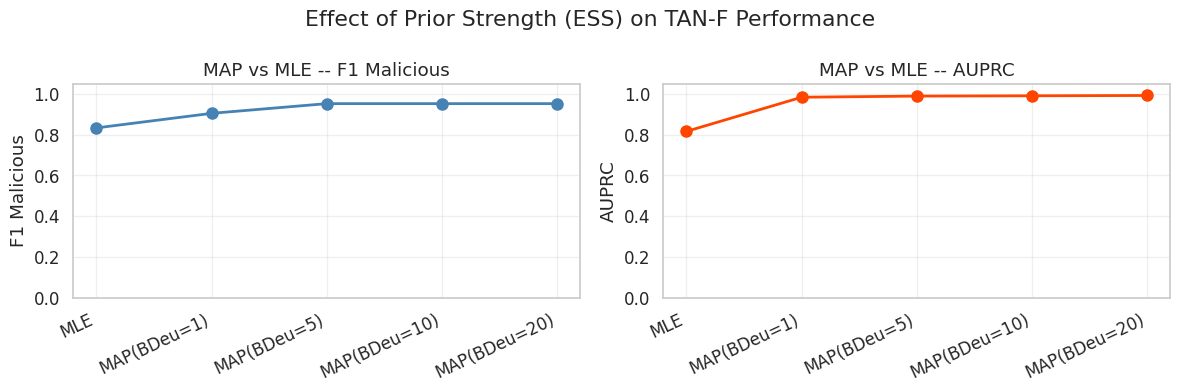

Saved map_vs_mle.png


In [42]:
# ── 12.1 Configurations ──────────────────────────────────────────────────────
estimator_configs = [('MLE', None)] + [('MAP', e) for e in ESS_GRID]
map_mle_results = []

pp_mm = preprocess_pipeline(X_tr2, X_val, X_test, y_tr2, apply_smote=True, random_state=RANDOM_STATE)
train_df_mm = pp_mm['X_tr'].copy(); train_df_mm['label'] = pp_mm['y_tr'].values
for c in train_df_mm.columns:
    train_df_mm[c] = train_df_mm[c].astype(int)
edges_mm, _, cols_mm = build_architecture(best_arch_key, pp_mm, train_df_mm)

print(f"MAP vs MLE experiment ({best_arch_key})")
print("-"*50)
for (est_type, ess) in estimator_configs:
    label = 'MLE' if est_type == 'MLE' else f'MAP(BDeu={ess})'
    print(f"  {label}...", end=' ')
    _, infer_mm, tr_mm = train_bn(edges_mm, train_df_mm, estimator=est_type,
                                  prior_type='BDeu', ess=ess if ess else BN_ESS_DEFAULT)
    vp, _, cache_mm = bn_predict_proba(infer_mm, pp_mm['X_va'], cols_mm)
    best_t, _ = calibrate_threshold(y_val, vp)
    tp_mm, _, _ = bn_predict_proba(infer_mm, pp_mm['X_te'], cols_mm, cache=cache_mm)
    yp = (tp_mm >= best_t).astype(int)
    m = compute_metrics_from_predictions(y_test, yp, tp_mm, threshold=best_t)
    m['Estimator'] = label
    m['Training_Time_s'] = round(tr_mm, 4)
    map_mle_results.append(m)
    print(f"F1={m['F1_Malicious']:.4f}  AUPRC={m['AUPRC']:.4f}")

df_map_mle = pd.DataFrame(map_mle_results).set_index('Estimator')
key_m = ['F1_Malicious', 'AUPRC', 'Recall_Malicious', 'FPR']
print("\n" + "="*60)
print(f"TABLE -- MAP vs MLE ({best_arch_key})")
print("="*60)
print(df_map_mle[key_m].to_string())
df_map_mle.to_csv('map_vs_mle.csv')
print("\nSaved map_vs_mle.csv")

# ── 12.2 Line chart ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
estimator_labels = df_map_mle.index.tolist()
x_pos = range(len(estimator_labels))
for ax, metric, color in [(axes[0], 'F1_Malicious', 'steelblue'), (axes[1], 'AUPRC', 'orangered')]:
    vals = df_map_mle[metric].values
    ax.plot(x_pos, vals, marker='o', color=color, lw=2, ms=8)
    ax.set_xticks(x_pos); ax.set_xticklabels(estimator_labels, rotation=25, ha='right')
    ax.set_ylabel(metric.replace('_', ' '))
    ax.set_title(f'MAP vs MLE -- {metric.replace("_", " ")}')
    ax.set_ylim(0, 1.05); ax.grid(alpha=0.3)
plt.suptitle(f'Effect of Prior Strength (ESS) on {best_arch_key} Performance')
plt.tight_layout()
plt.savefig('map_vs_mle.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved map_vs_mle.png")


## 13. Runtime Analysis

Training and inference time for **all 6 architectures**, measured on the
canonical Train2/Val/Test split — this replaces the previous pipeline's
"BN vs. ML baselines" runtime comparison with a like-for-like "which BN
architecture costs more" comparison, directly relevant to the new
manuscript route.


MACHINE / ENVIRONMENT CONFIGURATION (for runtime reproducibility)
  Platform        : Linux-6.6.122+-x86_64-with-glibc2.35
  Processor       : x86_64
  CPU cores       : 24
  RAM (total)     : 47.0 GB
  CPU frequency   : 0 MHz
  Memory speed    : unavailable (requires dmidecode/root)
  Python          : 3.12.13
  pandas          : 2.2.2
  numpy           : 2.0.2
  pgmpy           : 1.1.2
  scikit-learn    : 1.6.1
NOTE: runtimes below are measured on a single run, single-threaded
      inference (VariableElimination, no parallelism), on the
      canonical Train2/Val/Test split. Treat RELATIVE differences
      between architectures as the reliable signal; absolute
      seconds will vary across machines.

  NB        : structure=0.000s  train=0.051s  infer=0.344s
  SNBN      : structure=0.000s  train=0.061s  infer=0.418s
  HL        : structure=0.000s  train=0.057s  infer=0.310s
  TAN-F     : structure=0.923s  train=0.063s  infer=0.470s
  SIND-CL   : structure=0.029s  train=0.058s  inf

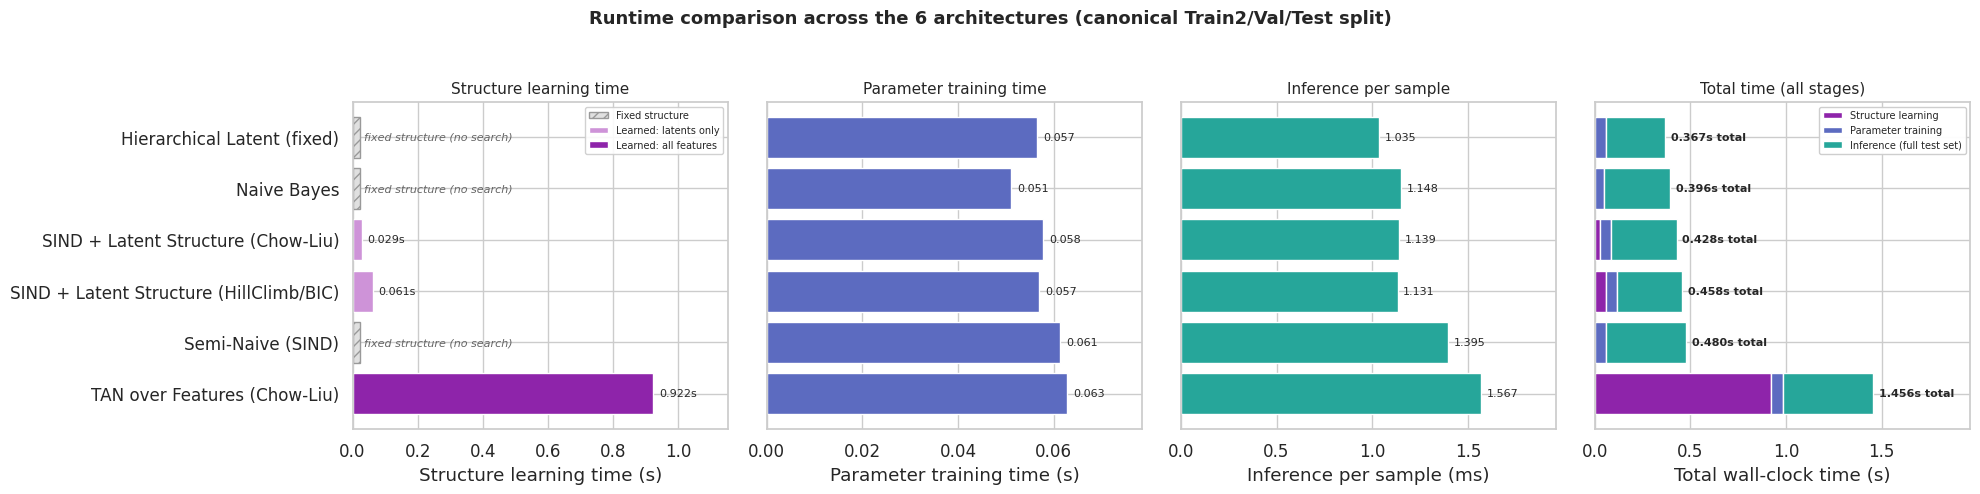


Saved runtime_analysis.csv | runtime_analysis.png


In [50]:
# ── 13.0 Machine / Environment Info ──────────────────────────────────────────
import platform
import os
import subprocess

print("="*70)
print("MACHINE / ENVIRONMENT CONFIGURATION (for runtime reproducibility)")
print("="*70)

print(f"  Platform        : {platform.platform()}")

# --------------------------------------------------------------------------
# CPU model
# --------------------------------------------------------------------------
try:
    from cpuinfo import get_cpu_info
    cpu_info = get_cpu_info()
    cpu_name = cpu_info.get("brand_raw", None)

    if cpu_name:
        print(f"  Processor       : {cpu_name}")
    else:
        print(f"  Processor       : {platform.processor() or 'unknown'}")
except Exception:
    print(f"  Processor       : {platform.processor() or 'unknown'}")

print(f"  CPU cores       : {os.cpu_count()}")

# --------------------------------------------------------------------------
# RAM
# --------------------------------------------------------------------------
try:
    import psutil

    ram_gb = psutil.virtual_memory().total / (1024**3)
    print(f"  RAM (total)     : {ram_gb:.1f} GB")

    # CPU frequency
    freq = psutil.cpu_freq()
    if freq is not None:
        print(f"  CPU frequency   : {freq.max:.0f} MHz")

    # Memory speed (Linux)
    try:
        output = subprocess.check_output(
            ["dmidecode", "-t", "memory"],
            stderr=subprocess.DEVNULL,
            text=True
        )

        mem_speed = None

        for line in output.splitlines():
            line = line.strip()

            if line.startswith("Configured Memory Speed:"):
                mem_speed = line.split(":", 1)[1].strip()
                break

            if line.startswith("Speed:") and "Unknown" not in line:
                mem_speed = line.split(":", 1)[1].strip()

        if mem_speed:
            print(f"  Memory speed    : {mem_speed}")
        else:
            print("  Memory speed    : unavailable")

    except Exception:
        print("  Memory speed    : unavailable (requires dmidecode/root)")

except ImportError:
    print("  RAM (total)     : unknown")

print(f"  Python          : {platform.python_version()}")
print(f"  pandas          : {pd.__version__}")
print(f"  numpy           : {np.__version__}")

import pgmpy
print(f"  pgmpy           : {pgmpy.__version__}")

import sklearn
print(f"  scikit-learn    : {sklearn.__version__}")

print("="*70)
print("NOTE: runtimes below are measured on a single run, single-threaded")
print("      inference (VariableElimination, no parallelism), on the")
print("      canonical Train2/Val/Test split. Treat RELATIVE differences")
print("      between architectures as the reliable signal; absolute")
print("      seconds will vary across machines.")
print()


# ── 13.1 Runtime comparison across architectures ────────────────────────────
runtime_rows = []
for arch_key in ARCHITECTURE_NAMES:
    # structure-learning time measured in isolation (this is the only call
    # to build_architecture for this architecture -- its edges are reused
    # below for training, so the ML structure-search cost is not paid twice)
    t_struct0 = time.time()
    edges_rt, learned_rt, cols_rt = build_architecture(arch_key, pp_final, train_df_final)
    t_struct = time.time() - t_struct0

    model_rt, infer_rt, tr_rt = train_bn(edges_rt, train_df_final, estimator='MAP', ess=BN_ESS_DEFAULT)
    _, inf_rt, _ = bn_predict_proba(infer_rt, pp_final['X_te'], cols_rt)

    runtime_rows.append({
        'Architecture'            : ARCHITECTURE_NAMES[arch_key],
        'Arch_Key'                : arch_key,
        'N_Edges'                 : len(edges_rt),
        'Has_Learned_Structure'   : learned_rt is not None and len(learned_rt) > 0,
        'Structure_Learning_Time_s': round(t_struct, 4),
        'Training_Time_s'         : round(tr_rt, 4),
        'Inference_Time_s'        : round(inf_rt, 4),
        'Test_Size'               : len(y_test),
        'Inference_per_sample_ms' : round(inf_rt / len(y_test) * 1000, 4),
        'Total_Time_s'            : round(t_struct + tr_rt + inf_rt, 4),
    })
    print(f"  {arch_key:10s}: structure={t_struct:.3f}s  train={tr_rt:.3f}s  infer={inf_rt:.3f}s")

df_runtime = pd.DataFrame(runtime_rows).set_index('Architecture')
print("\n" + "="*90)
print("TABLE -- Runtime Comparison (all 6 architectures)")
print("="*90)
print(df_runtime[['N_Edges', 'Structure_Learning_Time_s', 'Training_Time_s',
                  'Inference_per_sample_ms', 'Total_Time_s']].to_string())
df_runtime.to_csv('runtime_analysis.csv')

# ── 13.2 Bar chart ────────────────────────────────────────────────────────
df_plot = df_runtime.sort_values('Total_Time_s', ascending=False)
rt_idx = df_plot.index.tolist()

structure_color_learned_wide   = '#8E24AA'   # TAN-F: structure search over ALL features
structure_color_learned_latent = '#CE93D8'   # SIND-CL/SIND-HC: structure search over latents only
structure_color_fixed          = '#E0E0E0'   # NB/SNBN/HL: no structure search at all

fig, axes = plt.subplots(1, 4, figsize=(20, 0.55 * len(rt_idx) + 1.5), sharey=True)

# --- Panel 1: structure learning time -------------------------------------
ax = axes[0]
vals = df_plot['Structure_Learning_Time_s'].values
colors = []
for arch_key, v in zip(df_plot['Arch_Key'], vals):
    if v == 0:
        colors.append(structure_color_fixed)
    elif arch_key == 'TAN-F':
        colors.append(structure_color_learned_wide)
    else:
        colors.append(structure_color_learned_latent)
bars = ax.barh(rt_idx, np.where(vals == 0, np.nan, vals), color=colors)
xmax = max(vals.max(), 0.01) * 1.25
ax.set_xlim(0, xmax)
for i, (bar, val) in enumerate(zip(bars, vals)):
    if val == 0:
        ax.barh(rt_idx[i], xmax * 0.02, color=structure_color_fixed, hatch='///', edgecolor='#999')
        ax.text(xmax * 0.03, i, 'fixed structure (no search)', va='center', fontsize=8, color='#666', style='italic')
    else:
        ax.text(val + xmax * 0.015, i, f'{val:.3f}s', va='center', fontsize=8)
ax.set_xlabel('Structure learning time (s)')
ax.set_title('Structure learning time', fontsize=11)
legend_struct = [
    mpatches.Patch(facecolor=structure_color_fixed, edgecolor='#999', hatch='///', label='Fixed structure'),
    mpatches.Patch(facecolor=structure_color_learned_latent, label='Learned: latents only'),
    mpatches.Patch(facecolor=structure_color_learned_wide, label='Learned: all features'),
]
ax.legend(handles=legend_struct, loc='upper right', fontsize=7, framealpha=0.9)

# --- Panel 2: parameter training time -------------------------------------
ax = axes[1]
vals = df_plot['Training_Time_s'].values
bars = ax.barh(rt_idx, vals, color='#5C6BC0')
xmax = vals.max() * 1.25
ax.set_xlim(0, xmax)
for i, val in enumerate(vals):
    ax.text(val + xmax * 0.015, i, f'{val:.3f}', va='center', fontsize=8)
ax.set_xlabel('Parameter training time (s)')
ax.set_title('Parameter training time', fontsize=11)

# --- Panel 3: inference per sample -----------------------------------------
ax = axes[2]
vals = df_plot['Inference_per_sample_ms'].values
bars = ax.barh(rt_idx, vals, color='#26A69A')
xmax = vals.max() * 1.25
ax.set_xlim(0, xmax)
for i, val in enumerate(vals):
    ax.text(val + xmax * 0.015, i, f'{val:.3f}', va='center', fontsize=8)
ax.set_xlabel('Inference per sample (ms)')
ax.set_title('Inference per sample', fontsize=11)

# --- Panel 4: total wall-clock time, stacked by stage ----------------------
# Legend moved to 'upper right': the longest total bar (TAN-F) sits at the
# BOTTOM row (after sort + invert_yaxis), so the top-right corner is the one
# region guaranteed to stay clear of both bars and their "Xs total" labels,
# regardless of which architecture happens to be slowest.
ax = axes[3]
struct_s = df_plot['Structure_Learning_Time_s'].values
train_s  = df_plot['Training_Time_s'].values
infer_s  = df_plot['Inference_Time_s'].values  # total over the whole test set, seconds
y_pos = np.arange(len(rt_idx))
ax.barh(y_pos, struct_s, color=structure_color_learned_wide, label='Structure learning')
ax.barh(y_pos, train_s, left=struct_s, color='#5C6BC0', label='Parameter training')
ax.barh(y_pos, infer_s, left=struct_s + train_s, color='#26A69A', label='Inference (full test set)')
totals = struct_s + train_s + infer_s
xmax = totals.max() * 1.35   # a bit more headroom so the top-right legend never touches a bar
ax.set_xlim(0, xmax)
for i, tot in enumerate(totals):
    ax.text(tot + xmax * 0.015, i, f'{tot:.3f}s total', va='center', fontsize=8, fontweight='bold')
ax.set_xlabel('Total wall-clock time (s)')
ax.set_title('Total time (all stages)', fontsize=11)
ax.legend(loc='upper right', fontsize=7, framealpha=0.95)

for ax in axes:
    ax.invert_yaxis()

fig.suptitle('Runtime comparison across the 6 architectures (canonical Train2/Val/Test split)',
            fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('runtime_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved runtime_analysis.csv | runtime_analysis.png")

## 14. Final Architecture — CPD Tables & Interpretability Graph

The winning architecture (Section 6.4, trained in Section 8) is now
presented the same way the original SIND pipeline presented its single
architecture: Mutual-Information ranking, printed CPD tables for the
highest-MI nodes, and a circular interpretive graph.

The graph function below is a **generalisation** of the original
`plot_bn_interpretive`: it works for *any* of the 6 architectures. If the
winning architecture has latent nodes, they are drawn as a red inner ring
between the gold label and the blue outer ring of features; edges are
styled by role (label→node, domain hierarchy, or **ML-learned dependency**,
drawn as a bold dashed red line) so the reader can see at a glance which
part of the graph came from the structure-learning step.


In [51]:
# ── 14.1 Mutual Information (features + latents, on canonical Train2) ──────
X_tr_nm  = X_tr2.drop(columns=['user'], errors='ignore')
mi_raw   = mutual_info_classif(X_tr_nm[TOP_FEATURES], y_tr2, discrete_features='auto',
                               random_state=RANDOM_STATE)
mi_series = pd.Series(mi_raw, index=TOP_FEATURES).sort_values(ascending=False)

# Latent nodes don't have MI against the original continuous features, so
# their MI is computed directly against the label using the discretised
# latent column itself -- same basis (MI(node; label)) as the features.
latent_mi = {}
for lname in pp_final['latent_names']:
    latent_mi[lname] = mutual_info_classif(
        pp_final['X_tr'][[lname]], pp_final['y_tr'], discrete_features=True,
        random_state=RANDOM_STATE)[0]
mi_series_full = pd.concat([mi_series, pd.Series(latent_mi)])
mi_norm = (mi_series_full - mi_series_full.min()) / (mi_series_full.max() - mi_series_full.min() + 1e-9)

print("Top-10 nodes by Mutual Information (features + latents):")
print(mi_series_full.sort_values(ascending=False).head(10).to_string())


Top-10 nodes by Mutual Information (features + latents):
device_max_daily_device_events     0.531421
device_mean_daily_device_events    0.492655
device_active_days                 0.478378
device_device_events_total         0.459287
device_usb_connects                0.458651
device_offhour_device_count        0.456196
device_offhour_device_ratio        0.444795
device_std_daily_device_events     0.422610
logon_total_logoffs_day            0.407031
email_n_email                      0.393834


In [52]:
# ── 14.2 CPD tables for the highest-MI nodes actually present in the model ─
def print_cpd_table(model, node, mi_series_full_):
    cpd = model.get_cpds(node)
    if cpd is None:
        print(f"  [{node}] -- CPD not found"); return
    parents = cpd.variables[1:]
    states  = cpd.state_names
    mi_val  = mi_series_full_.get(node, 0.0)
    print(f"\n{'-'*70}")
    print(f"  Node   : {node}")
    print(f"  MI     : {mi_val:.4f}   |   Parents: {parents or 'None (root)'}")
    print(f"{'-'*70}")
    try:
        import itertools
        card0 = cpd.values.shape[0]
        df_cpd = pd.DataFrame(cpd.values.reshape(card0, -1),
                              index=[f"s{s}" for s in states.get(node, range(card0))])
        if parents:
            parent_states = [states.get(p, list(range(N_BINS))) for p in parents]
            combos = list(itertools.product(*parent_states))
            df_cpd.columns = [str(c) for c in combos]
            df_cpd.index.name = node
            df_cpd.columns.name = str(parents)
        print(df_cpd.round(3).to_string())
    except Exception as e:
        print(f"  (reshape error: {e})")


print("="*70)
print(f"CONDITIONAL PROBABILITY TABLES -- {best_arch_key} ({ARCHITECTURE_NAMES[best_arch_key]})")
print("="*70)
nodes_to_show = ['label'] + mi_series_full.sort_values(ascending=False).index.tolist()
shown = 0
for node in nodes_to_show:
    if node in model_best.nodes():
        print_cpd_table(model_best, node, mi_series_full)
        shown += 1
    if shown >= 6:   # label + top-5 by MI that are actually present in the model
        break

# Export all CPDs
cpd_rows = []
for node in model_best.nodes():
    cpd = model_best.get_cpds(node)
    if cpd is None:
        continue
    try:
        for k, v in enumerate(cpd.values.flatten()):
            cpd_rows.append({'node': node, 'entry': k, 'probability': round(float(v), 6),
                             'MI': round(mi_series_full.get(node, 0.0), 4)})
    except Exception:
        pass
pd.DataFrame(cpd_rows).to_csv('cpd_tables_best.csv', index=False)
print("\nSaved cpd_tables_best.csv (all CPD entries, best architecture)")


CONDITIONAL PROBABILITY TABLES -- TAN-F (TAN over Features (Chow-Liu))

----------------------------------------------------------------------
  Node   : label
  MI     : 0.0000   |   Parents: None (root)
----------------------------------------------------------------------
        0
s0  0.683
s1  0.317

----------------------------------------------------------------------
  Node   : device_max_daily_device_events
  MI     : 0.5314   |   Parents: ['device_std_daily_device_events', 'label']
----------------------------------------------------------------------
['device_std_daily_device_events', 'label']  (np.int64(0), np.int64(0))  (np.int64(0), np.int64(1))  (np.int64(1), np.int64(0))  (np.int64(1), np.int64(1))  (np.int64(2), np.int64(0))  (np.int64(2), np.int64(1))  (np.int64(3), np.int64(0))  (np.int64(3), np.int64(1))
device_max_daily_device_events                                                                                                                                      

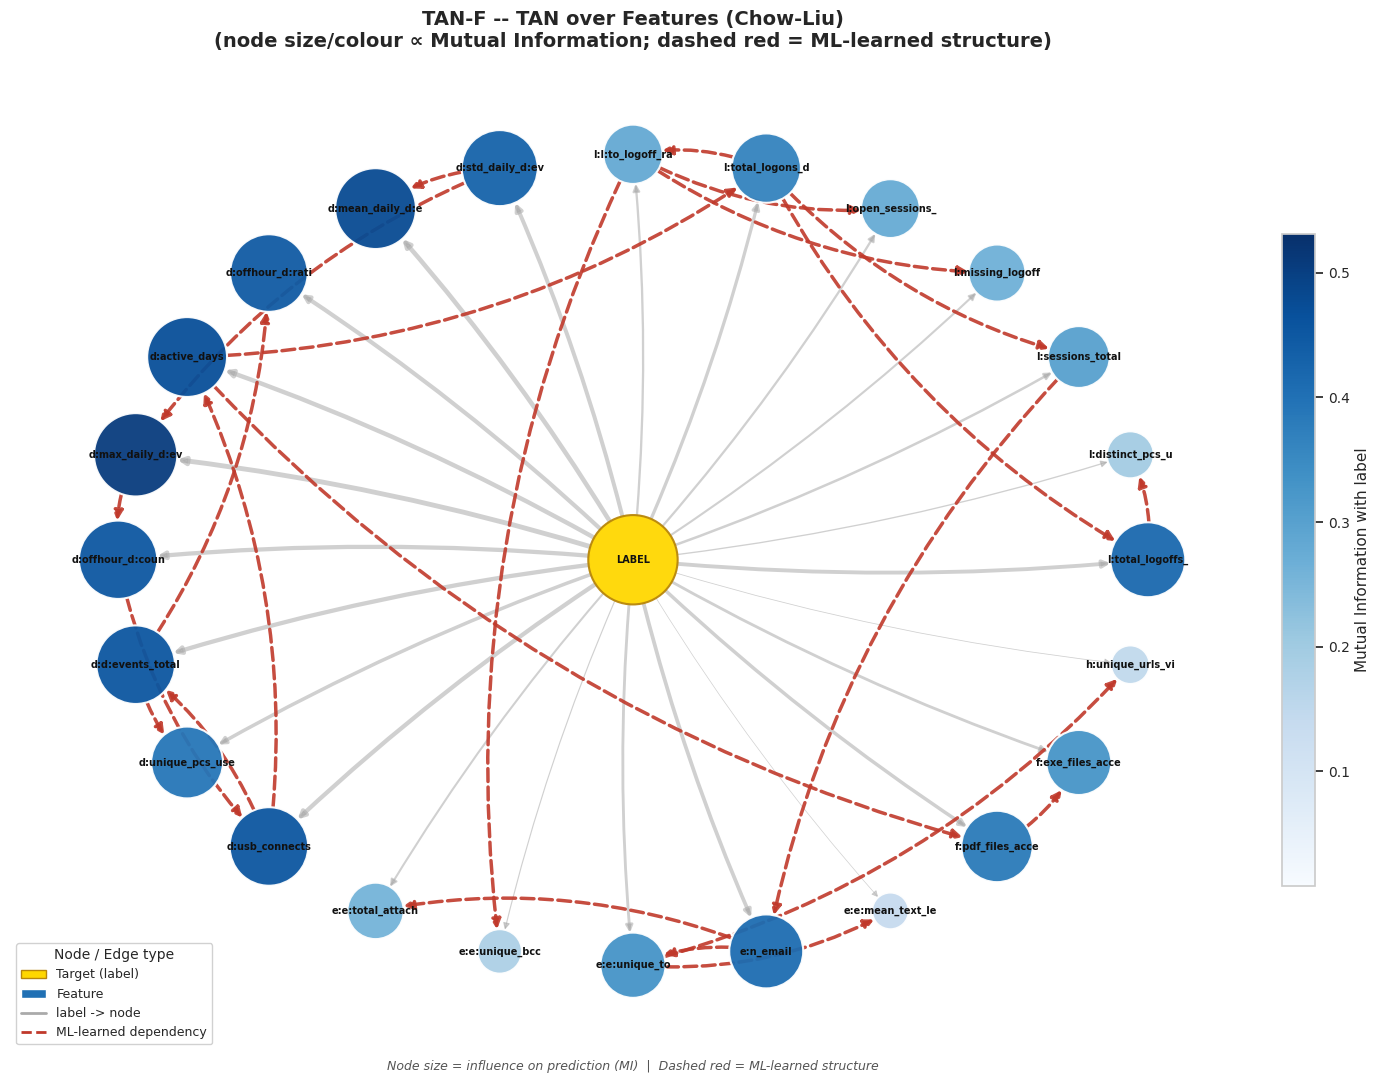

Saved bn_interpretive_best.png


In [53]:
# ── 14.3 Generalised interpretability graph (any of the 6 architectures) ───
def node_type(node, latent_names):
    if node == 'label':
        return 'label'
    if node in latent_names:
        return 'latent'
    return 'feature'


def plot_bn_interpretive(model, edges, mi_series_full_, mi_norm_, latent_names,
                         learned_edges=None, domain_mapping=None,
                         title="Bayesian Network", figsize=(14, 11), save_path=None):
    """
    Generalised interpretability plot, works for ANY of the 6 architectures:
      - label:   gold, centre
      - latent:  red inner ring (only drawn if the architecture has latents)
      - feature: blue outer ring, size/colour proportional to Mutual Information
    Edge styling distinguishes three roles:
      - label -> node                          light grey
      - domain hierarchy / intra-domain chain   dark grey, curved
      - ML-LEARNED edges (Chow-Liu / HillClimb  bold red, dashed
        latent-latent structure, or the Chow-Liu
        feature-feature TAN tree)
    """
    if domain_mapping is None:
        domain_mapping = DOMAIN_MAPPING
    if learned_edges is None:
        learned_edges = []
    learned_set = set(tuple(e) for e in learned_edges)

    G = nx.DiGraph()
    G.add_edges_from(edges)

    latent_nodes  = [n for n in G.nodes() if n in latent_names]
    feature_nodes = [n for n in G.nodes() if n not in latent_names and n != 'label']

    # layout: label centre; latents inner ring (if any); features outer ring
    pos = {'label': (0.0, 0.0)}
    if latent_nodes:
        angles_l = np.linspace(0, 2 * np.pi, len(latent_nodes), endpoint=False)
        for node, ang in zip(latent_nodes, angles_l):
            pos[node] = (1.7 * np.cos(ang), 1.7 * np.sin(ang))

    domain_order = []
    for d_feats in domain_mapping.values():
        domain_order += [f for f in d_feats if f in feature_nodes]
    remaining = [f for f in feature_nodes if f not in domain_order]
    ordered = domain_order + remaining
    angles_f = np.linspace(0, 2 * np.pi, len(ordered), endpoint=False)
    radius_f = 3.6 if latent_nodes else 3.2
    for node, ang in zip(ordered, angles_f):
        pos[node] = (radius_f * np.cos(ang), radius_f * np.sin(ang))

    MIN_S, MAX_S = 700, 3600
    node_sizes, node_colors, node_ec = [], [], []
    for node in G.nodes():
        t = node_type(node, latent_names)
        if t == 'label':
            node_sizes.append(MAX_S * 1.15); node_colors.append('#FFD700'); node_ec.append('#B8860B')
        elif t == 'latent':
            mi_v = float(mi_norm_.get(node, 0.4))
            node_sizes.append(MIN_S + (MAX_S - MIN_S) * mi_v)
            node_colors.append(plt.cm.Reds(0.35 + 0.55 * mi_v)); node_ec.append('#7B241C')
        else:
            mi_v = float(mi_norm_.get(node, 0.2))
            node_sizes.append(MIN_S + (MAX_S - MIN_S) * mi_v)
            node_colors.append(plt.cm.Blues(0.25 + 0.70 * mi_v)); node_ec.append('white')
    size_dict = dict(zip(G.nodes(), node_sizes))

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_facecolor('white'); ax.grid(False)

    label_edges = [(u, v) for u, v in edges if u == 'label']
    hier_edges  = [(u, v) for u, v in edges if u != 'label' and (u, v) not in learned_set]
    ml_edges    = [(u, v) for u, v in edges if (u, v) in learned_set]

    if label_edges:
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=label_edges, edge_color='#AAAAAA',
                               alpha=0.55, arrows=True, arrowsize=10,
                               width=[0.5 + 3.0 * float(mi_norm_.get(v, 0.2)) for _, v in label_edges],
                               node_size=[size_dict[n] for n in G.nodes()],
                               arrowstyle='-|>', connectionstyle='arc3,rad=0.05')
    if hier_edges:
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=hier_edges, edge_color='#555555',
                               alpha=0.75, arrows=True, arrowsize=10,
                               width=[1.2 + 2.0 * float(mi_norm_.get(v, 0.2)) for _, v in hier_edges],
                               node_size=[size_dict[n] for n in G.nodes()],
                               arrowstyle='-|>', connectionstyle='arc3,rad=0.30')
    if ml_edges:
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=ml_edges, edge_color='#C0392B',
                               alpha=0.9, arrows=True, arrowsize=14, width=2.5, style='dashed',
                               node_size=[size_dict[n] for n in G.nodes()],
                               arrowstyle='-|>', connectionstyle='arc3,rad=0.15')

    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=list(size_dict.values()),
                           node_color=node_colors, edgecolors=node_ec, linewidths=1.5, alpha=0.95)

    labels = {}
    for node in G.nodes():
        if node == 'label':
            labels[node] = 'LABEL'
        elif node in latent_names:
            labels[node] = node.replace('latent_', 'L:')
        else:
            short = (node.replace('device_', 'd:').replace('logon_', 'l:')
                    .replace('email_email_', 'e:e:').replace('email_', 'e:')
                    .replace('file_', 'f:').replace('http_', 'h:'))
            labels[node] = short[:16]
    nx.draw_networkx_labels(G, pos, labels, ax=ax, font_size=7, font_weight='bold', font_color='#111111')

    sm = cm.ScalarMappable(cmap=plt.cm.Blues,
                           norm=mcolors.Normalize(vmin=float(mi_series_full_.min()),
                                                  vmax=float(mi_series_full_.max())))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, fraction=0.025, pad=0.02)
    cbar.set_label('Mutual Information with label', fontsize=11)
    cbar.ax.tick_params(labelsize=10)

    legend_elements = [mpatches.Patch(facecolor='#FFD700', edgecolor='#B8860B', label='Target (label)')]
    if latent_nodes:
        legend_elements.append(mpatches.Patch(facecolor=plt.cm.Reds(0.7), edgecolor='#7B241C',
                                              label='Latent (domain)'))
    legend_elements.append(mpatches.Patch(facecolor=plt.cm.Blues(0.75), edgecolor='white', label='Feature'))
    legend_elements.append(plt.Line2D([0], [0], color='#AAAAAA', lw=2, label='label -> node'))
    if hier_edges:
        legend_elements.append(plt.Line2D([0], [0], color='#555555', lw=2, label='hierarchy / domain-chain'))
    if ml_edges:
        legend_elements.append(plt.Line2D([0], [0], color='#C0392B', lw=2, ls='dashed',
                                          label='ML-learned dependency'))
    ax.legend(handles=legend_elements, loc='lower left', fontsize=9, framealpha=0.9,
             title='Node / Edge type', title_fontsize=10)

    ax.annotate('Node size = influence on prediction (MI)  |  '
               'Dashed red = ML-learned structure',
               xy=(0.5, -0.02), xycoords='axes fraction', ha='center', fontsize=9,
               style='italic', color='#555')

    ax.set_title(title, fontsize=14, fontweight='bold', pad=16)
    ax.axis('off')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()
    return fig


fig_bn = plot_bn_interpretive(
    model_best, edges_best, mi_series_full, mi_norm, pp_final['latent_names'],
    learned_edges=learned_best,
    title=f'{best_arch_key} -- {ARCHITECTURE_NAMES[best_arch_key]}\n'
         '(node size/colour \u221d Mutual Information; dashed red = ML-learned structure)',
    save_path='bn_interpretive_best.png',
)
print("Saved bn_interpretive_best.png")


## 15. Export All Results

In [54]:
# ── 15.1 Print file inventory ────────────────────────────────────────────────
import os

output_files = [
    ('fold_composition.csv',                    'Table -- per-fold class balance (Section 6)'),
    ('architecture_cv_summary.csv',              'Table -- 30-fold CV mean/std/CI, all architectures'),
    ('wilcoxon_tests.csv',                       'Table -- Wilcoxon tests, best vs. every other architecture'),
    ('table_best_architecture_single_run.csv',   'Table -- canonical single-run result, best architecture'),
    ('smote_ablation.csv',                       'Table -- SMOTE ablation, best architecture'),
    ('imbalance_sensitivity.csv',                'Table -- imbalance sensitivity, best architecture'),
    ('cpt_stability.csv',                        'Table -- CPT stability (bootstrap), best architecture'),
    ('map_vs_mle.csv',                           'Table -- MAP vs MLE, best architecture'),
    ('runtime_analysis.csv',                     'Table -- runtime, all 6 architectures'),
    ('cpd_tables_best.csv',                      'Table -- all CPD entries, best architecture'),
    # Figures
    ('fold_composition.png',                     'Figure -- class balance per fold'),
    ('architecture_comparison_heatmap.png',      'Figure -- metric heatmap, all architectures'),
    ('architecture_comparison_f1_significance.png', 'Figure -- F1 bar chart with Wilcoxon significance'),
    ('calibration_reliability.png',              'Figure -- reliability diagram, best architecture'),
    ('prob_distribution_best.png',               'Figure -- P(malicious) distribution, best architecture'),
    ('confusion_matrix_best.png',                'Figure -- confusion matrix, best architecture'),
    ('smote_ablation.png',                       'Figure -- SMOTE ablation'),
    ('imbalance_sensitivity.png',                'Figure -- imbalance sensitivity'),
    ('cpt_stability.png',                        'Figure -- CPT std distributions'),
    ('map_vs_mle.png',                           'Figure -- MAP vs MLE'),
    ('runtime_analysis.png',                     'Figure -- runtime comparison, all architectures'),
    ('bn_interpretive_best.png',                 'Figure -- interpretive graph, best architecture'),
]

print("=" * 70)
print("EXPORT SUMMARY -- FILES GENERATED")
print("=" * 70)
for fname, desc in output_files:
    exists = "OK" if os.path.exists(fname) else "MISSING"
    print(f"  [{exists:7s}]  {fname:<45s}  {desc}")

print()
print(f"Winning architecture : {best_arch_key} ({ARCHITECTURE_NAMES[best_arch_key]})")
print("All metrics were derived from compute_metrics_from_predictions().")
print("Precision / Recall / F1 refer to the MALICIOUS class (class = 1).")
print(f"Bootstrap CI: 95%, {N_BOOTSTRAP} resamples.")
print(f"Statistical tests: two-sided Wilcoxon signed-rank, paired on "
     f"{N_SPLITS_CV*N_REPEATS_CV} folds ({N_SPLITS_CV}-fold x {N_REPEATS_CV} repeats).")


EXPORT SUMMARY -- FILES GENERATED
  [OK     ]  fold_composition.csv                           Table -- per-fold class balance (Section 6)
  [OK     ]  architecture_cv_summary.csv                    Table -- 30-fold CV mean/std/CI, all architectures
  [OK     ]  wilcoxon_tests.csv                             Table -- Wilcoxon tests, best vs. every other architecture
  [OK     ]  table_best_architecture_single_run.csv         Table -- canonical single-run result, best architecture
  [OK     ]  smote_ablation.csv                             Table -- SMOTE ablation, best architecture
  [OK     ]  imbalance_sensitivity.csv                      Table -- imbalance sensitivity, best architecture
  [OK     ]  cpt_stability.csv                              Table -- CPT stability (bootstrap), best architecture
  [OK     ]  map_vs_mle.csv                                 Table -- MAP vs MLE, best architecture
  [OK     ]  runtime_analysis.csv                           Table -- runtime, all 6 archit